# Co-authorship Network and Community Structure

### Author-order-weighted collaboration in agent-based modelling research

This notebook builds the **co-authorship network** of the screened ABM corpus and analyses its
**community structure**: which groups of researchers cluster together, what they work on, and how the
network has grown.

| Quantity | Value |
|---|---|
| Corpus records | 322,742 |
| ABM-positive papers | 88,954 |
| Papers with author names | 322,461 (99.9 %) |
| Author-paper links | 1,523,363 |
| Mean authors per paper | 4.72 |

### Author order is weighted, not ignored

Counting every co-authorship pair equally treats "first author and fifth author" the same as "first
and second author", which is not how credit or collaboration works. Each author therefore carries a
**position weight**, and the strength of an edge is the product of the two weights:

| Position | Weight | Rationale |
|---|---|---|
| First author | **1.00** | conventionally the lead contributor |
| Last author | **0.75** | conventionally the senior author |
| Second author | **0.60** | usually a close collaborator |
| Other middle authors | **0.35** | contributed, but the pairing is weaker evidence |

A pair that shares a two-author paper therefore contributes 1.00, two middle authors on the same
paper contribute 0.35 x 0.35 = 0.12, and a pair sharing several papers accumulates their sum. Edge
weights are **summed across papers**, and the weighted degree of an author is the sum of the weights
of their edges. This is what separates a close, repeated collaboration from a one-off large-team
paper, and the weighted network is used for community detection.

### Scope and one limitation

Everything is restricted to **1990-2025**; records dated 2026 or later are dropped because the harvest
year is incomplete. Two scopes are used: the **full corpus** for overall scale, and the
**ABM-positive** papers for the substantive analysis.

Author identity comes from the name string alone, with no ORCID-based disambiguation, so common names
merge. Section 2 measures this and Section 10 explains how it constrains the interpretation.

## 1. Setup

In [1]:
from __future__ import annotations

import gzip
import json
import re
import textwrap
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

sns.set_theme(style="ticks", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.labelsize": 9,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "legend.frameon": False, "axes.spines.top": False, "axes.spines.right": False,
})

C = {"net": "#1f4e79", "abm": "#2e86c1", "alt": "#c0392b", "acc": "#1e8449",
     "grey": "#7f8c8d", "warm": "#e07b39", "purple": "#7d3c98"}

BASE = Path(r"<PROJECT_ROOT>")
CACHE_DIR = BASE / "data_cache"
CACHE = CACHE_DIR / "abm_llm_corpus_cache_v3.parquet"
AUTHOR_SIDECAR = CACHE_DIR / "author_meta.jsonl.gz"
SRC_JSONL = BASE / "LLM" / "abm_filter_corpus_three_stage.jsonl"
POS_CACHE = CACHE_DIR / "author_positions.parquet"
FIG_DIR = BASE / "figures_network"
FIG_DIR.mkdir(parents=True, exist_ok=True)
COMBINED_DIR = FIG_DIR / "_combined"

LAST_YEAR = 2025            # 2026 is an incomplete harvest year and is excluded everywhere
FIRST_YEAR = 1990

# position weight -> strength contributed by that author to every pair they form
POSITION_WEIGHT = {"first": 1.00, "last": 0.75, "second": 0.60, "middle": 0.35}


def position_weight(index: int, n_authors: int) -> float:
    """Weight of the author at 1-based `index` on a paper with `n_authors` authors."""
    if n_authors <= 1:
        return 1.0
    if index == 1:
        return POSITION_WEIGHT["first"]
    if index == n_authors:
        return POSITION_WEIGHT["last"]
    if index == 2:
        return POSITION_WEIGHT["second"]
    return POSITION_WEIGHT["middle"]


REGION_OF_CHINA = {"TW": "Taiwan (China)", "HK": "Hong Kong (China)", "MO": "Macao (China)"}
COUNTRY_NAMES = {
    "US": "United States", "CN": "China", "GB": "United Kingdom", "DE": "Germany",
    "CA": "Canada", "AU": "Australia", "IN": "India", "FR": "France", "IT": "Italy",
    "ES": "Spain", "JP": "Japan", "NL": "Netherlands", "BR": "Brazil", "KR": "South Korea",
    "IR": "Iran", "RU": "Russia", "SE": "Sweden", "CH": "Switzerland", "PL": "Poland",
    "TR": "Turkey", "SA": "Saudi Arabia", "BE": "Belgium", "AT": "Austria", "IL": "Israel",
    "DK": "Denmark", "SG": "Singapore", "MY": "Malaysia", "PT": "Portugal", "NO": "Norway",
    "FI": "Finland", "GR": "Greece", "MX": "Mexico", "ZA": "South Africa", "IE": "Ireland",
    "NZ": "New Zealand", "CZ": "Czechia", "EG": "Egypt", "PK": "Pakistan", "AR": "Argentina",
    "CL": "Chile", "CO": "Colombia", "TH": "Thailand", "VN": "Vietnam", "ID": "Indonesia",
    "NG": "Nigeria", "HU": "Hungary", "RO": "Romania", "UA": "Ukraine", "RS": "Serbia",
}


# ---------------------------------------------------------------- label text that the font can draw
# 13,558 author names in this corpus carry non-ASCII characters: Unicode hyphens (U+2010 in
# 'lozano-montes hector'), Hungarian accents, Turkish dotless i, Polish l-stroke, Cyrillic, and a few
# Chinese institutional strings the author extraction mis-assigned as names. matplotlib silently drops
# any glyph the font lacks, so labels lose characters and the run logs "Glyph 8208 missing from font".
# Every label that reaches a figure passes through here first.
import unicodedata as _unicodedata

_DASHES = {"\u2010", "\u2011", "\u2012", "\u2013", "\u2014", "\u2015", "\u2212", "\u2043"}
_FOLD = {"\u0131": "i", "\u0142": "l", "\u0141": "L", "\u00f8": "o", "\u00d8": "O",
         "\u00e6": "ae", "\u00c6": "AE", "\u00df": "ss", "\u0111": "d", "\u0110": "D",
         "\u0167": "t", "\u0127": "h", "\u014b": "n", "\u00f0": "d", "\u00fe": "th",
         "\u2019": "'", "\u2018": "'", "\u201c": '"', "\u201d": '"'}
_CYR = {"\u0430": "a", "\u0431": "b", "\u0432": "v", "\u0433": "g", "\u0434": "d",
        "\u0435": "e", "\u0436": "zh", "\u0437": "z", "\u0438": "i", "\u0439": "i",
        "\u043a": "k", "\u043b": "l", "\u043c": "m", "\u043d": "n", "\u043e": "o",
        "\u043f": "p", "\u0440": "r", "\u0441": "s", "\u0442": "t", "\u0443": "u",
        "\u0444": "f", "\u0445": "kh", "\u0446": "ts", "\u0447": "ch", "\u0448": "sh",
        "\u0449": "shch", "\u044b": "y", "\u044d": "e", "\u044e": "iu", "\u044f": "ia",
        "\u0451": "e", "\u044c": "", "\u044a": ""}


def ascii_label(text) -> str:
    """Fold a label to characters the plotting font can actually draw.

    `text` is cast with `str()` and never assumed to be a pandas scalar: this function is passed to
    Series.map in places, and letting a pandas object through caused
    `AttributeError: 'Series' object has no attribute 'normalize'`.
    """
    if not isinstance(text, str):
        text = "" if text is None else str(text)
    s = "".join("-" if ch in _DASHES else ch for ch in text)
    s = _unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not _unicodedata.combining(ch))
    s = "".join(_FOLD.get(ch, ch) for ch in s)
    s = "".join(_CYR.get(ch.lower(), ch) if ch.lower() in _CYR else ch for ch in s)
    return "".join(ch for ch in s if ord(ch) < 128).strip()


def abbreviate(name: str) -> str:
    """Name string to the requested short form.

    The name strings in this corpus are stored surname-first ('batty michael'), so the label is the
    surname initial followed by the surname, i.e. 'batty michael' -> 'B. Batty'.
    """
    parts = [p for p in ascii_label(name).split() if p]
    if not parts:
        return ascii_label(name)
    if len(parts) == 1:
        return parts[0].title()
    surname = parts[0]
    return f"{surname[0].upper()}. {surname.title()}"


def country_label(code: str) -> str:
    """ISO-2 code to a readable name, with Taiwan / Hong Kong / Macao reported as part of China."""
    key = str(code).strip().upper()
    if key in REGION_OF_CHINA:
        return REGION_OF_CHINA[key]
    return COUNTRY_NAMES.get(key, key)


_fig_n = 0


def save(fig, name: str):
    """Write the composite to a scratch folder and each panel as its own PNG and PDF."""
    global _fig_n
    _fig_n += 1
    COMBINED_DIR.mkdir(parents=True, exist_ok=True)
    _save_retry(fig, COMBINED_DIR / f"{name}.png")
    plt.show()
    plt.close(fig)
    outs = _split_panels(fig, name)
    print(f"  [fig {_fig_n:02d}] {name} -> " + ", ".join(outs) + f"  ({FIG_DIR.name}/)")
    return outs


def _save_retry(fig, path, **kw):
    """Windows occasionally raises Errno 22/13 on a transiently locked file; retry briefly."""
    import time as _t
    last = None
    for _ in range(5):
        try:
            fig.savefig(path, **kw)
            return True
        except OSError as exc:
            last = exc
            _t.sleep(0.4)
    print(f"    [warn] write failed after retries: {last}")
    return False


TARGET_PANEL_IN = (7.2, 5.0)


def _split_panels(fig, name):
    """One file per panel, at a fixed publication size, with small consistent type."""
    panels = [ax for ax in fig.axes if ax.get_label() != "<colorbar>"]
    outs = []
    for i, ax in enumerate(panels):
        for other in fig.axes:
            other.set_visible(other is ax)
        if fig._suptitle is not None:
            fig._suptitle.set_visible(False)
        try:
            fig.set_layout_engine("none")
        except Exception:
            pass
        fig.set_size_inches(TARGET_PANEL_IN[0] * 1.32, TARGET_PANEL_IN[1] * 1.28)
        ax.set_position([0.15, 0.17, 0.82, 0.78])
        ax.set_title(re.sub(r"^[A-F]\.\s*", "", ax.get_title().replace("\n", " ")), fontsize=10)
        for t in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            t.set_fontsize(min(t.get_fontsize() * 1.1, 9.5))
        ax.xaxis.label.set_fontsize(min(ax.xaxis.label.get_fontsize() * 1.1, 9))
        ax.yaxis.label.set_fontsize(min(ax.yaxis.label.get_fontsize() * 1.1, 9))
        leg = ax.get_legend()
        if leg is not None:
            for t in leg.get_texts():
                t.set_fontsize(min(t.get_fontsize() * 1.05, 8))
        stem = f"{name}_{chr(ord('a') + i)}"
        path = FIG_DIR / f"{stem}.png"
        for _ in range(3):
            _save_retry(fig, path, bbox_inches="tight")
            try:
                from PIL import Image
                with Image.open(path) as im:
                    w, h = im.size
            except Exception:
                break
            sx, sy = TARGET_PANEL_IN[0] / (w / 200.0), TARGET_PANEL_IN[1] / (h / 200.0)
            if abs(sx - 1) < 0.04 and abs(sy - 1) < 0.04:
                break
            sw, sh = fig.get_size_inches()
            fig.set_size_inches(sw * sx, sh * sy)
            ax.set_position([0.15, 0.17, 0.82, 0.78])
        _save_retry(fig, FIG_DIR / f"{stem}.pdf")
        outs.append(stem)
    plt.close(fig)
    return outs


def wrap(label, width=30):
    return "\n".join(textwrap.wrap(str(label), width))


print("networkx", nx.__version__, "| pandas", pd.__version__, "| seaborn", sns.__version__)
print("figures ->", FIG_DIR)

networkx 3.4.2 | pandas 2.2.3 | seaborn 0.13.2
figures -> <PROJECT_ROOT>\figures_network


## 2. Data, and the name-ambiguity problem

The author sidecar stores the resolved author names plus the countries and institutions of each
record, but not the author **order**, which is needed for the weighting. The order is extracted from
the raw records once into a compact cache: for every paper, the ordered list of author names.

Before building any network it is worth measuring how badly names merge, because identity comes from
the name string alone.

In [2]:
def build_position_cache(src: Path, dst: Path, chunk_size: int = 50_000) -> None:
    """Extract, for every record, the ordered list of resolved author names."""
    rows = []
    reader = pd.read_json(src, lines=True, chunksize=chunk_size, dtype=False)
    for i, chunk in enumerate(reader, start=1):
        for doc_id, raw in zip(chunk["doc_id"], chunk["authors_std"]):
            names = []
            if isinstance(raw, str) and raw.strip():
                try:
                    parsed = json.loads(raw)
                except Exception:
                    parsed = []
                if isinstance(parsed, list):
                    for a in parsed:
                        if not isinstance(a, dict):
                            continue
                        nm = (str(a.get("last_name") or "").strip() + " " +
                              str(a.get("first_name") or "").strip()).strip().lower()
                        nm = re.sub(r"\s+", " ", nm)
                        if nm:
                            names.append(nm)
                    names = list(dict.fromkeys(names))
            rows.append({"doc_id": doc_id, "authors_ordered": names})
        print(f"    chunk {i:,} -> {len(rows):,} records", flush=True)
    out = pd.DataFrame(rows)
    out.to_parquet(dst, index=False)
    print(f"    written {dst.name} ({dst.stat().st_size / 1024**2:.1f} MB)")


if POS_CACHE.exists() and POS_CACHE.stat().st_mtime >= SRC_JSONL.stat().st_mtime:
    pos = pd.read_parquet(POS_CACHE)
    print(f"loaded {POS_CACHE.name}: {len(pos):,} records")
else:
    print(f"building {POS_CACHE.name} from the raw corpus (one pass) ...")
    build_position_cache(SRC_JSONL, POS_CACHE)
    pos = pd.read_parquet(POS_CACHE)

pos["authors_ordered"] = pos["authors_ordered"].apply(
    lambda v: v.tolist() if isinstance(v, np.ndarray) else (v if isinstance(v, list) else []))
pos["n_authors"] = pos["authors_ordered"].apply(len)
print(f"records with >= 1 author: {int((pos['n_authors'] > 0).sum()):,}")
print(f"mean authors per paper: {pos['n_authors'].mean():.2f}")

loaded author_positions.parquet: 331,011 records


records with >= 1 author: 330,680
mean authors per paper: 4.76


In [3]:
corpus = pd.read_parquet(CACHE, columns=[
    "doc_id", "year", "llama_abm_is_abm", "llama_abm_methodology",
    "llama_llm_has_llm", "llama_primary_domain",
    "llama_topic_keywords", "llama_agent_types"])
corpus["year_num"] = pd.to_numeric(corpus["year"], errors="coerce")

# ---------------------------------------------------------------- classical-ABM scope
# See ABM_LLM_visualization.ipynb / tools/classic_abm.py. Stage 1 accepted 88,954 records as ABM,
# but 72,064 of those name a non-classical method, so the networks are rebuilt on the 16,890 that are
# actually agent-based modelling.
CLASSIC_ABM_RE = re.compile(
    r"agent[- ]based|individual[- ]based|micro[- ]?simulat|spatial abm|"
    r"cellular automat|activity[- ]based", re.I)
_stage1_positive = corpus["llama_abm_is_abm"] == 1
_classic_abm = corpus["llama_abm_methodology"].astype("string").str.contains(CLASSIC_ABM_RE, na=False)
corpus["llama_abm_is_abm"] = (_stage1_positive & _classic_abm).astype(int)
corpus.loc[_stage1_positive & ~_classic_abm, "llama_llm_has_llm"] = -1
print(f"classical-ABM scope: stage-1 positives {int(_stage1_positive.sum()):,} -> "
      f"{int(corpus['llama_abm_is_abm'].sum()):,}")
corpus = corpus[corpus["year_num"].between(FIRST_YEAR, LAST_YEAR)].copy()
corpus["year_num"] = corpus["year_num"].astype(int)

corpus = corpus.merge(pos[["doc_id", "authors_ordered", "n_authors"]], on="doc_id", how="left")
corpus["authors_ordered"] = corpus["authors_ordered"].apply(
    lambda v: v if isinstance(v, list) else [])
corpus["n_authors"] = corpus["n_authors"].fillna(0).astype(int)

print(f"records in {FIRST_YEAR}-{LAST_YEAR}: {len(corpus):,}")
print(f"  ABM-positive: {int((corpus['llama_abm_is_abm'] == 1).sum()):,}")

# ---- author country lookup, used by the later figures
def load_author_index(path: Path) -> dict:
    index = {}
    with gzip.open(path, "rt", encoding="utf-8") as fh:
        for line in fh:
            try:
                rec = json.loads(line)
            except Exception:
                continue
            index[rec["d"]] = rec
    return index


AUTHORS = load_author_index(AUTHOR_SIDECAR)
_docs = set(corpus["doc_id"])
AUTHORS = {d: r for d, r in AUTHORS.items() if d in _docs}
print(f"author records matched: {len(AUTHORS):,}")

# ---- name ambiguity diagnostics
papers_per_name = Counter()
for names in corpus["authors_ordered"]:
    for nm in names:
        papers_per_name[nm] += 1
freq = pd.Series(papers_per_name).sort_values(ascending=False)
print(f"\ndistinct author names: {len(freq):,}")
print(f"  appearing once    : {int((freq == 1).sum()):,} ({100 * (freq == 1).mean():.1f} %)")
print(f"  with 20+ papers   : {int((freq >= 20).sum()):,}")
print(f"  with 100+ papers  : {int((freq >= 100).sum()):,}")
print("\nmost frequent author strings (almost certainly several people sharing a name):")
display(freq.head(12).rename("papers").to_frame())

classical-ABM scope: stage-1 positives 89,416 -> 17,311


records in 1990-2025: 311,558
  ABM-positive: 16,722


author records matched: 311,558



distinct author names: 737,099
  appearing once    : 520,626 (70.6 %)
  with 20+ papers   : 4,631
  with 100+ papers  : 246

most frequent author strings (almost certainly several people sharing a name):


,papers
wang wei,572
liu yang,412
zhang wei,400
hu yuan,397
wang lei,354
zhang jun,343
wang xin,320
wang jun,319
li wei,313
lima joão a.c.,293


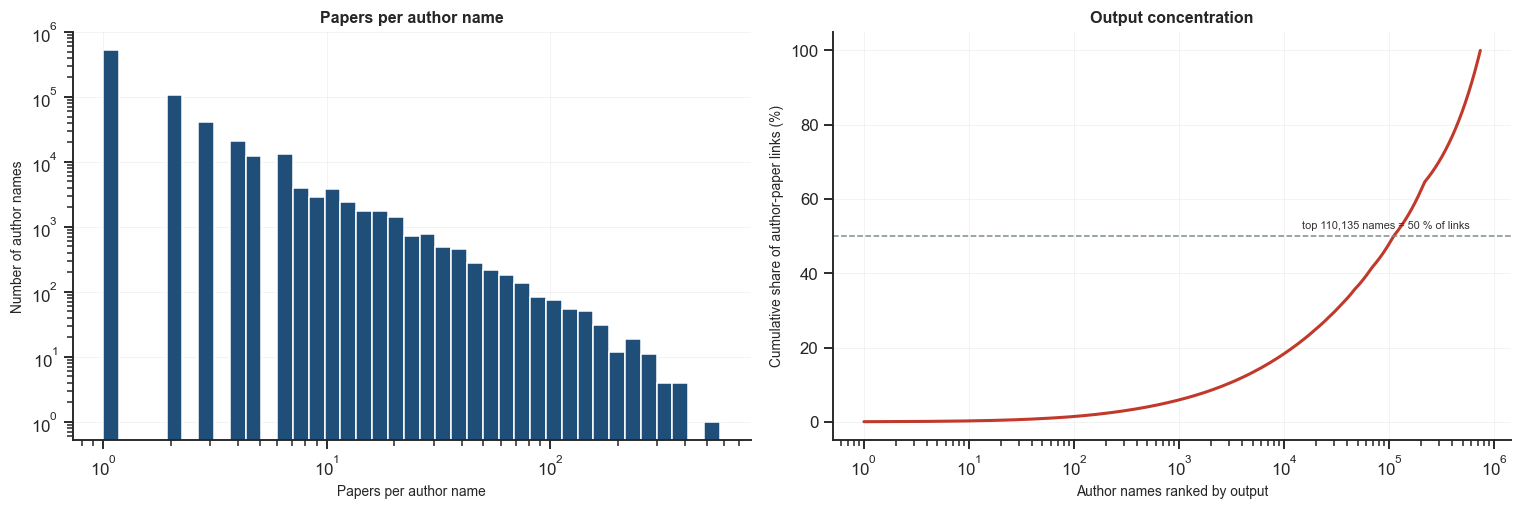

  [fig 01] net01_name_ambiguity -> net01_name_ambiguity_a, net01_name_ambiguity_b  (figures_network/)


['net01_name_ambiguity_a', 'net01_name_ambiguity_b']

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.8))

ax = axes[0]
_bins = np.logspace(0, np.log10(max(freq.max(), 10)), 40)
ax.hist(freq.to_numpy(), bins=_bins, color=C["net"], edgecolor="white")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Papers per author name")
ax.set_ylabel("Number of author names")
ax.set_title("Papers per author name")

ax = axes[1]
_sorted = np.sort(freq.to_numpy())[::-1]
_cum = np.cumsum(_sorted) / _sorted.sum() * 100
ax.plot(np.arange(1, len(_sorted) + 1), _cum, color=C["alt"], lw=2.0)
ax.set_xscale("log")
ax.set_xlabel("Author names ranked by output")
ax.set_ylabel("Cumulative share of author-paper links (%)")
ax.set_title("Output concentration")
_k50 = int(np.searchsorted(_cum, 50) + 1)
ax.axhline(50, color=C["grey"], ls="--", lw=1.0)
ax.text(len(_sorted) * 0.02, 52, f"top {_k50:,} names = 50 % of links", fontsize=7.2,
        color="#333333")

fig.tight_layout()
save(fig, "net01_name_ambiguity")

## 3. Building the position-weighted network

One pass over the ordered author lists produces the edges for both scopes. For a paper with authors
`a1 ... ak`, every pair `(ai, aj)` contributes `w(ai) * w(aj)`, where `w` is the position weight
defined above. Edges are undirected and their weight is the sum over all shared papers, so the weight
measures the strength and repetition of a collaboration rather than just its existence.

In [5]:
def build_edges(frame, weighted: bool = True):
    """Undirected co-authorship edges; weight = sum over papers of w(i) * w(j)."""
    edges = Counter()
    for names in frame["authors_ordered"]:
        k = len(names)
        if k < 2:
            continue
        w = [position_weight(i + 1, k) for i in range(k)]
        for i in range(k):
            for j in range(i + 1, k):
                a, b = names[i], names[j]
                key = (a, b) if a <= b else (b, a)
                edges[key] += (w[i] * w[j]) if weighted else 1.0
    return edges


full = corpus
abm_meta = corpus[corpus["llama_abm_is_abm"] == 1]
print(f"papers used: full = {len(full):,} | ABM-positive = {len(abm_meta):,}")

edges_full = build_edges(full, weighted=True)
edges_abm = build_edges(abm_meta, weighted=True)
print(f"edges: full = {len(edges_full):,} | ABM-positive = {len(edges_abm):,}")


def to_graph(edges):
    g = nx.Graph()
    g.add_weighted_edges_from((a, b, w) for (a, b), w in edges.items())
    return g


G_full = to_graph(edges_full)
G = to_graph(edges_abm)
print(f"nodes: full = {G_full.number_of_nodes():,} | ABM-positive = {G.number_of_nodes():,}")

papers used: full = 311,558 | ABM-positive = 16,722


edges: full = 4,322,673 | ABM-positive = 188,088


nodes: full = 728,771 | ABM-positive = 46,423


In [6]:
# how much does the weighting change the picture?
_e_unw = build_edges(abm_meta, weighted=False)
_w = np.array(list(edges_abm.values()))
_u = np.array([_e_unw[k] for k in edges_abm])
print("edge weight versus shared-paper count (ABM-positive):")
print(f"  edges                          : {len(_w):,}")
print(f"  total weighted strength        : {_w.sum():,.0f}")
print(f"  total shared-paper pairs       : {_u.sum():,.0f}")
print(f"  weight per shared paper        : {_w.sum() / _u.sum():.3f}")
print(f"  edges from a single paper      : {int((_u == 1).sum()):,} "
      f"({100 * (_u == 1).mean():.1f} %)")
print(f"  edges from 3+ papers           : {int((_u >= 3).sum()):,} "
      f"({100 * (_u >= 3).mean():.1f} %)")
print(f"  median weight, 1-paper edges   : {np.median(_w[_u == 1]):.3f}")
print(f"  median weight, 3+-paper edges  : {np.median(_w[_u >= 3]):.3f}")

_wd = pd.Series(dict(G.degree(weight="weight"))).sort_values(ascending=False)
_ud = pd.Series(dict(G.degree())).sort_values(ascending=False)
_rank = pd.DataFrame({"weighted_degree": _wd, "degree": _ud}).dropna()
_rank["rank_weighted"] = _rank["weighted_degree"].rank(ascending=False)
_rank["rank_plain"] = _rank["degree"].rank(ascending=False)
_shifts = (_rank["rank_plain"] - _rank["rank_weighted"]).abs()
print(f"\nrank correlation between weighted and plain degree: "
      f"{_rank['weighted_degree'].corr(_rank['degree'], method='spearman'):.3f}")
print(f"authors whose rank moves by more than 1,000 places: {int((_shifts > 1000).sum()):,}")

edge weight versus shared-paper count (ABM-positive):
  edges                          : 188,088
  total weighted strength        : 59,122
  total shared-paper pairs       : 219,091
  weight per shared paper        : 0.270
  edges from a single paper      : 169,159 (89.9 %)
  edges from 3+ papers           : 5,902 (3.1 %)
  median weight, 1-paper edges   : 0.210
  median weight, 3+-paper edges  : 0.962



rank correlation between weighted and plain degree: 0.730
authors whose rank moves by more than 1,000 places: 39,268


## 4. Structure of the two networks

Standard summary statistics for both scopes, followed by the degree distributions. The weighted
degree is the quantity of interest: it counts collaborators in proportion to how strong each
collaboration is.

In [7]:
def net_summary(g, label):
    n, m = g.number_of_nodes(), g.number_of_edges()
    deg = np.array([d for _, d in g.degree()])
    wdeg = np.array([d for _, d in g.degree(weight="weight")])
    comps = sorted(nx.connected_components(g), key=len, reverse=True)
    giant = g.subgraph(comps[0]) if comps else g
    return {
        "network": label,
        "authors (nodes)": n,
        "edges": m,
        "edges from 1 paper": int(sum(1 for w in dict(g.edges).keys() if False)) or
        int(sum(1 for _, _, d in g.edges(data=True) if abs(d["weight"] - 1.0) < 1e-9)),
        "mean degree": float(deg.mean()) if len(deg) else 0.0,
        "median degree": float(np.median(deg)) if len(deg) else 0.0,
        "max degree": int(deg.max()) if len(deg) else 0,
        "mean weighted degree": float(wdeg.mean()) if len(wdeg) else 0.0,
        "density": float(nx.density(g)) if n > 1 else 0.0,
        "connected components": len(comps),
        "giant component nodes": giant.number_of_nodes(),
        "giant share (%)": 100 * giant.number_of_nodes() / n if n else 0.0,
        "mean clustering": float(nx.average_clustering(g)) if n else 0.0,
    }


summary = pd.DataFrame([net_summary(G_full, "full corpus"),
                        net_summary(G, "ABM-positive")]).set_index("network")
display(summary.T)

# a worked example of the weighting, so the effect is concrete
_rows = []
for names in abm_meta["authors_ordered"].head(4000):
    if len(names) >= 4:
        _rows.append(names[:4])
        if len(_rows) >= 3:
            break
for names in _rows:
    k = len(names)
    pairs = [(names[i], names[j], position_weight(i + 1, k) * position_weight(j + 1, k))
             for i in range(k) for j in range(i + 1, k)]
    print(f"\npaper with {k} authors: " + ", ".join(f"{n}({position_weight(i + 1, k):.2f})"
                                                   for i, n in enumerate(names)))
    for a, b, w in pairs[:4]:
        print(f"    {a} - {b}: {w:.3f}")

network,full corpus,ABM-positive
authors (nodes),7.287710e+05,46423.000000
edges,4.322673e+06,188088.000000
edges from 1 paper,0.000000e+00,0.000000
mean degree,1.186291e+01,8.103225
median degree,6.000000e+00,5.000000
max degree,2.068000e+03,289.000000
mean weighted degree,3.597922e+00,2.547096
density,1.627799e-05,0.000175
connected components,3.898300e+04,4673.000000
giant component nodes,5.582840e+05,24331.000000



paper with 4 authors: rose devin(1.00), edwards brandon p.m.(0.60), kett ross(0.35), yodzis michael(0.75)
    rose devin - edwards brandon p.m.: 0.600
    rose devin - kett ross: 0.350
    rose devin - yodzis michael: 0.750
    edwards brandon p.m. - kett ross: 0.210

paper with 4 authors: zhang wensi(1.00), yao tiechui(0.60), zhou fei(0.35), jin hongyang(0.75)
    zhang wensi - yao tiechui: 0.600
    zhang wensi - zhou fei: 0.350
    zhang wensi - jin hongyang: 0.750
    yao tiechui - zhou fei: 0.210

paper with 4 authors: yang zhen(1.00), guo yuanfang(0.60), yang ruijie(0.35), huang di(0.75)
    yang zhen - guo yuanfang: 0.600
    yang zhen - yang ruijie: 0.350
    yang zhen - huang di: 0.750
    guo yuanfang - yang ruijie: 0.210


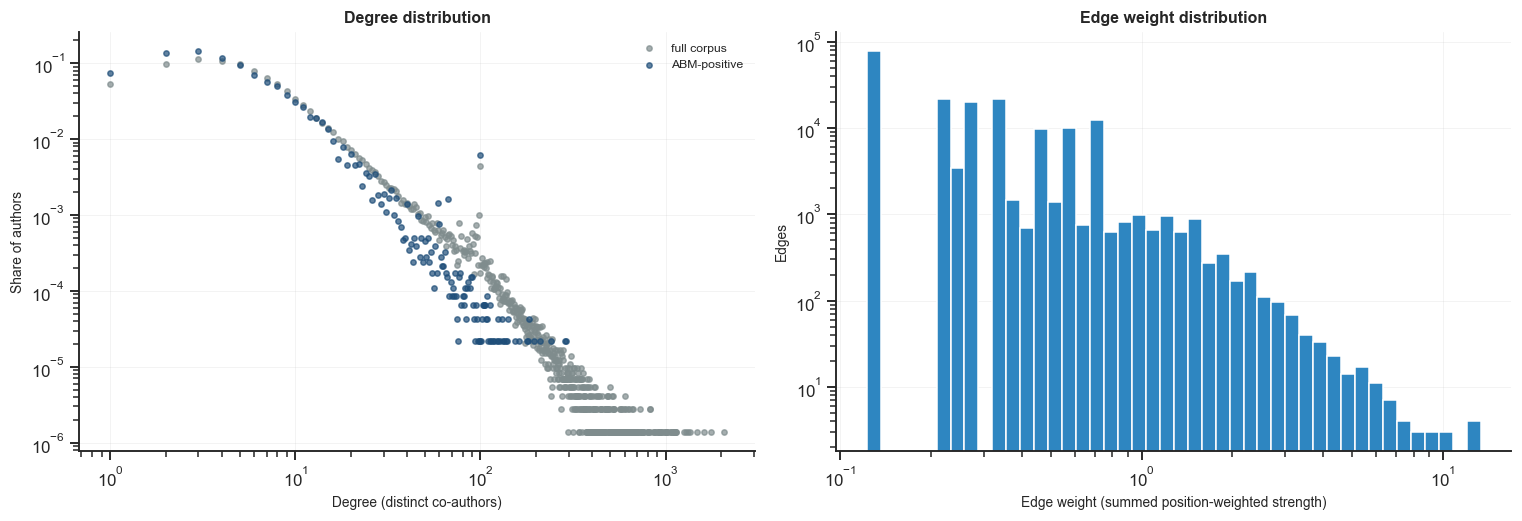

  [fig 02] net02_degree_distribution -> net02_degree_distribution_a, net02_degree_distribution_b  (figures_network/)


['net02_degree_distribution_a', 'net02_degree_distribution_b']

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.9))

ax = axes[0]
for g, label, color in [(G_full, "full corpus", C["grey"]), (G, "ABM-positive", C["net"])]:
    deg = np.array([d for _, d in g.degree()])
    deg = deg[deg > 0]
    vals, counts = np.unique(deg, return_counts=True)
    ax.scatter(vals, counts / counts.sum(), s=12, color=color, alpha=0.7, label=label)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Degree (distinct co-authors)")
ax.set_ylabel("Share of authors")
ax.set_title("Degree distribution")
ax.legend(fontsize=8)

ax = axes[1]
_wv = np.array(list(edges_abm.values()))
ax.hist(_wv, bins=np.logspace(np.log10(max(_wv.min(), 0.01)), np.log10(_wv.max()), 45),
        color=C["abm"], edgecolor="white")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Edge weight (summed position-weighted strength)")
ax.set_ylabel("Edges")
ax.set_title("Edge weight distribution")

fig.tight_layout()
save(fig, "net02_degree_distribution")

## 5. Growth of the collaboration network

The network is rebuilt cumulatively for each year, so each point uses all papers up to that year. The
weighted mean degree is the average total collaboration strength per author.

In [9]:
years = list(range(FIRST_YEAR, LAST_YEAR + 1))
_rows = []
for y in years:
    sub = abm_meta[abm_meta["year_num"] <= y]
    if not len(sub):
        continue
    g = to_graph(build_edges(sub))
    if not g.number_of_nodes():
        continue
    deg = np.array([d for _, d in g.degree()])
    wdeg = np.array([d for _, d in g.degree(weight="weight")])
    comps = sorted(nx.connected_components(g), key=len, reverse=True)
    _rows.append({
        "year": y, "authors": g.number_of_nodes(), "edges": g.number_of_edges(),
        "mean_degree": float(deg.mean()), "mean_weighted_degree": float(wdeg.mean()),
        "giant_share": 100 * len(comps[0]) / g.number_of_nodes(),
    })
    if y % 5 == 0:
        print(f"  {y}: {_rows[-1]['authors']:,} authors, {_rows[-1]['edges']:,} edges, "
              f"mean weighted degree {_rows[-1]['mean_weighted_degree']:.2f}")

growth = pd.DataFrame(_rows).set_index("year")
display(growth.loc[[y for y in (1995, 2000, 2005, 2010, 2015, 2020, LAST_YEAR)
                   if y in growth.index]].style.format("{:,.2f}"))

  1990: 5 authors, 10 edges, mean weighted degree 1.43
  1995: 150 authors, 220 edges, mean weighted degree 1.43
  2000: 796 authors, 1,140 edges, mean weighted degree 1.40
  2005: 2,573 authors, 4,749 edges, mean weighted degree 1.56


  2010: 6,808 authors, 14,617 edges, mean weighted degree 1.71


  2015: 14,718 authors, 36,514 edges, mean weighted degree 1.94


  2020: 27,092 authors, 87,142 edges, mean weighted degree 2.22


  2025: 46,423 authors, 188,088 edges, mean weighted degree 2.55


,authors,edges,mean_degree,mean_weighted_degree,giant_share
year,,,,,
1995,150.00,220.00,2.93,1.43,15.33
2000,796.00,"1,140.00",2.86,1.40,4.77
2005,"2,573.00","4,749.00",3.69,1.56,7.07
2010,"6,808.00","14,617.00",4.29,1.71,12.44
2015,"14,718.00","36,514.00",4.96,1.94,27.40
2020,"27,092.00","87,142.00",6.43,2.22,41.61
2025,"46,423.00","188,088.00",8.10,2.55,52.41


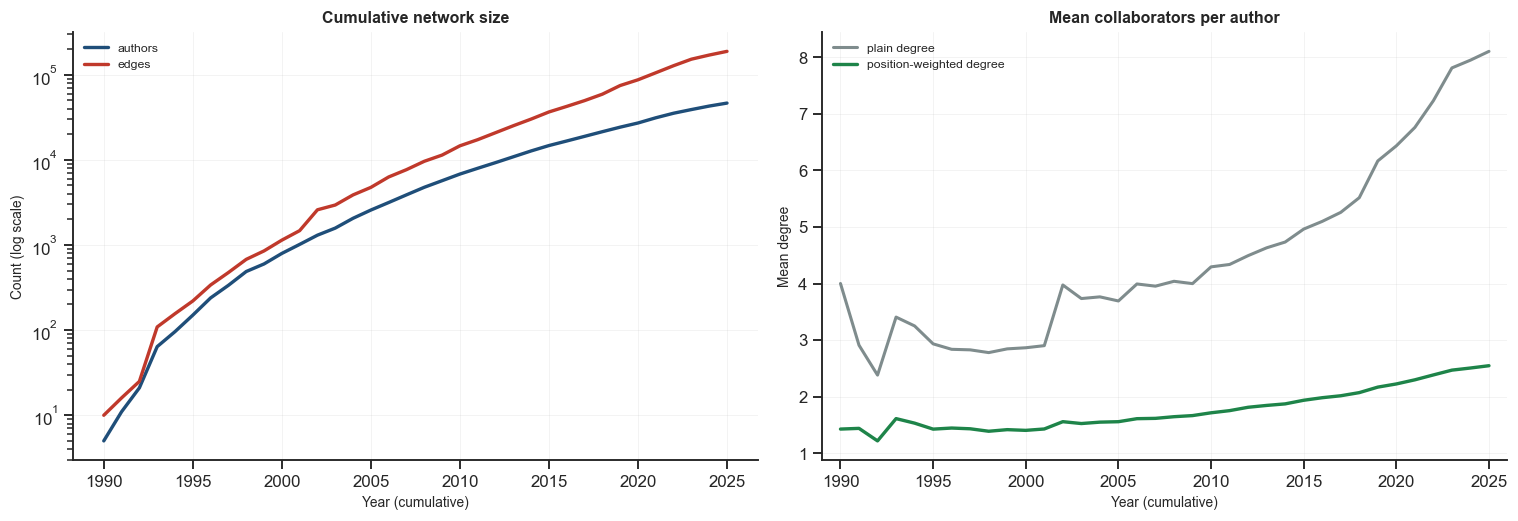

  [fig 03] net03_network_growth -> net03_network_growth_a, net03_network_growth_b  (figures_network/)


['net03_network_growth_a', 'net03_network_growth_b']

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14.0, 4.9))

ax = axes[0]
ax.plot(growth.index, growth["authors"], color=C["net"], lw=2.2, label="authors")
ax.plot(growth.index, growth["edges"], color=C["alt"], lw=2.2, label="edges")
ax.set_yscale("log")
ax.set_xlabel("Year (cumulative)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Cumulative network size")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(growth.index, growth["mean_degree"], color=C["grey"], lw=2.0, label="plain degree")
ax.plot(growth.index, growth["mean_weighted_degree"], color=C["acc"], lw=2.2,
        label="position-weighted degree")
ax.set_xlabel("Year (cumulative)")
ax.set_ylabel("Mean degree")
ax.set_title("Mean collaborators per author")
ax.legend(fontsize=8)
ax.set_xlim(FIRST_YEAR - 1, LAST_YEAR + 1)

fig.tight_layout()
save(fig, "net03_network_growth")

## 6. Pruning the graph

The complete ABM network is far too large to draw: the giant component alone holds about a hundred
thousand author names. The graph is therefore pruned in two steps, and the rule is stated so every
number printed later can be traced back to it.

| Purpose | Rule | Result |
|---|---|---|
| Structure and community detection | giant component, degree >= 10 | see output |
| Layout, centrality and labels | giant component, **top 1 % by weighted degree** | see output |

Degree pruning removes one-off co-authors: the pairs who appear together on a single large-team paper
and never again. The layout prunes to the top 1 %, roughly a thousand authors, because that is the
part of the network that can actually be read on a page and because it is the step whose cost grows
fastest with node count.

Structure measurements in Sections 4 and 5 are deliberately **not** pruned: they describe the complete
network, and pruning would silently change them.


In [11]:
COMM_START = 2010
DEG_PRUNE = 10          # community detection keeps authors with at least this many co-authors
LAYOUT_PCT = 0.01       # layout/centrality keeps the top 1 % of the giant component by weighted degree
comm_meta = abm_meta[abm_meta["year_num"] >= COMM_START].copy()
Gc = to_graph(build_edges(comm_meta))
print(f"community-detection scope: {COMM_START}-{LAST_YEAR}")
print(f"  papers {len(comm_meta):,} | nodes {Gc.number_of_nodes():,} | "
      f"edges {Gc.number_of_edges():,}")

comps = sorted(nx.connected_components(Gc), key=len, reverse=True)
Gg = Gc.subgraph(comps[0]).copy()
print(f"  components {len(comps):,} | giant {Gg.number_of_nodes():,} "
      f"({100 * Gg.number_of_nodes() / Gc.number_of_nodes():.1f} % of nodes), "
      f"{Gg.number_of_edges():,} edges")

# ---- prune for community detection: giant component, degree >= DEG_PRUNE
_deg_all = dict(Gg.degree())
Gp = Gg.subgraph([n for n, d in _deg_all.items() if d >= DEG_PRUNE]).copy()
print(f"\npruning for community detection: degree >= {DEG_PRUNE}")
print(f"  {Gg.number_of_nodes():,} -> {Gp.number_of_nodes():,} nodes | "
      f"{Gg.number_of_edges():,} -> {Gp.number_of_edges():,} edges")

communities = sorted(nx.community.louvain_communities(Gp, seed=0, resolution=1.0, weight="weight"),
                     key=len, reverse=True)
mod_w = nx.community.modularity(Gp, communities, weight="weight")
print(f"  weighted Louvain: {len(communities):,} communities, modularity {mod_w:.4f}")

Gu = nx.Graph()
Gu.add_nodes_from(Gp.nodes())
Gu.add_edges_from(Gp.edges())
communities_uw = sorted(nx.community.louvain_communities(Gu, seed=0, resolution=1.0,
                                                         weight=None), key=len, reverse=True)
mod_u = nx.community.modularity(Gu, communities_uw, weight=None)
print(f"  unweighted Louvain: {len(communities_uw):,} communities, modularity {mod_u:.4f}")

_sizes = np.array([len(c) for c in communities])
print(f"  community size: median {int(np.median(_sizes))}, largest {_sizes[0]:,}, "
      f">= 100 members {int((_sizes >= 100).sum())}")

member_of = {n: k for k, comm in enumerate(communities) for n in comm}
member_of_uw = {n: k for k, comm in enumerate(communities_uw) for n in comm}

# ---- prune much harder for the layout and the centrality measures
_wdeg_all = dict(Gg.degree(weight="weight"))
_n_layout = max(int(Gg.number_of_nodes() * LAYOUT_PCT), 100)
_top_names = sorted(_wdeg_all, key=lambda n: _wdeg_all[n], reverse=True)[:_n_layout]
Gt = Gg.subgraph(_top_names).copy()
print(f"\npruning for the layout: top {LAYOUT_PCT:.0%} by weighted degree")
print(f"  {Gg.number_of_nodes():,} -> {Gt.number_of_nodes():,} nodes "
      f"({100 * Gt.number_of_nodes() / Gg.number_of_nodes():.1f} % kept) | "
      f"{Gt.number_of_edges():,} edges")
print(f"  weighted-degree cut-off: {_wdeg_all[_top_names[-1]]:.2f}")

# the layout graph gets its own partition, so colours and labels describe exactly what is drawn
layout_comms = sorted(nx.community.louvain_communities(Gt, seed=0, weight="weight"),
                      key=len, reverse=True)
layout_member_of = {n: k for k, comm in enumerate(layout_comms) for n in comm}
print(f"  communities in the layout graph: {len(layout_comms):,}, "
      f"largest {[len(c) for c in layout_comms[:10]]}")


community-detection scope: 2010-2025
  papers 14,189 | nodes 42,237 | edges 177,407


  components 4,159 | giant 21,710 (51.4 % of nodes), 126,529 edges



pruning for community detection: degree >= 10
  21,710 -> 8,136 nodes | 126,529 -> 77,884 edges


  weighted Louvain: 121 communities, modularity 0.9223


  unweighted Louvain: 122 communities, modularity 0.9260
  community size: median 34, largest 393, >= 100 members 36

pruning for the layout: top 1% by weighted degree
  21,710 -> 217 nodes (1.0 % kept) | 770 edges
  weighted-degree cut-off: 22.77
  communities in the layout graph: 40, largest [23, 20, 18, 16, 13, 13, 13, 12, 10, 6]


In [12]:
# agreement between the weighted and unweighted partitions
from itertools import combinations


def _pair_set(part):
    s = set()
    for comm in part:
        for a, b in combinations(sorted(comm), 2):
            s.add((a, b))
    return s


_pw, _pu = _pair_set(communities), _pair_set(communities_uw)
_inter = len(_pw & _pu)
print(f"co-membership pairs, weighted  : {len(_pw):,}")
print(f"co-membership pairs, unweighted: {len(_pu):,}")
print(f"pairs agreed by both           : {_inter:,}")
print(f"Jaccard agreement              : {_inter / len(_pw | _pu):.4f}")
print(f"\nmodularity: weighted {mod_w:.4f} vs unweighted {mod_u:.4f} "
      f"(difference {mod_w - mod_u:+.4f})")
print("A higher weighted modularity means the paper-count weighting sharpens the community "
      "boundaries rather than blurring them.")

co-membership pairs, weighted  : 645,905
co-membership pairs, unweighted: 721,977
pairs agreed by both           : 423,332
Jaccard agreement              : 0.4482

modularity: weighted 0.9223 vs unweighted 0.9260 (difference -0.0037)
A higher weighted modularity means the paper-count weighting sharpens the community boundaries rather than blurring them.


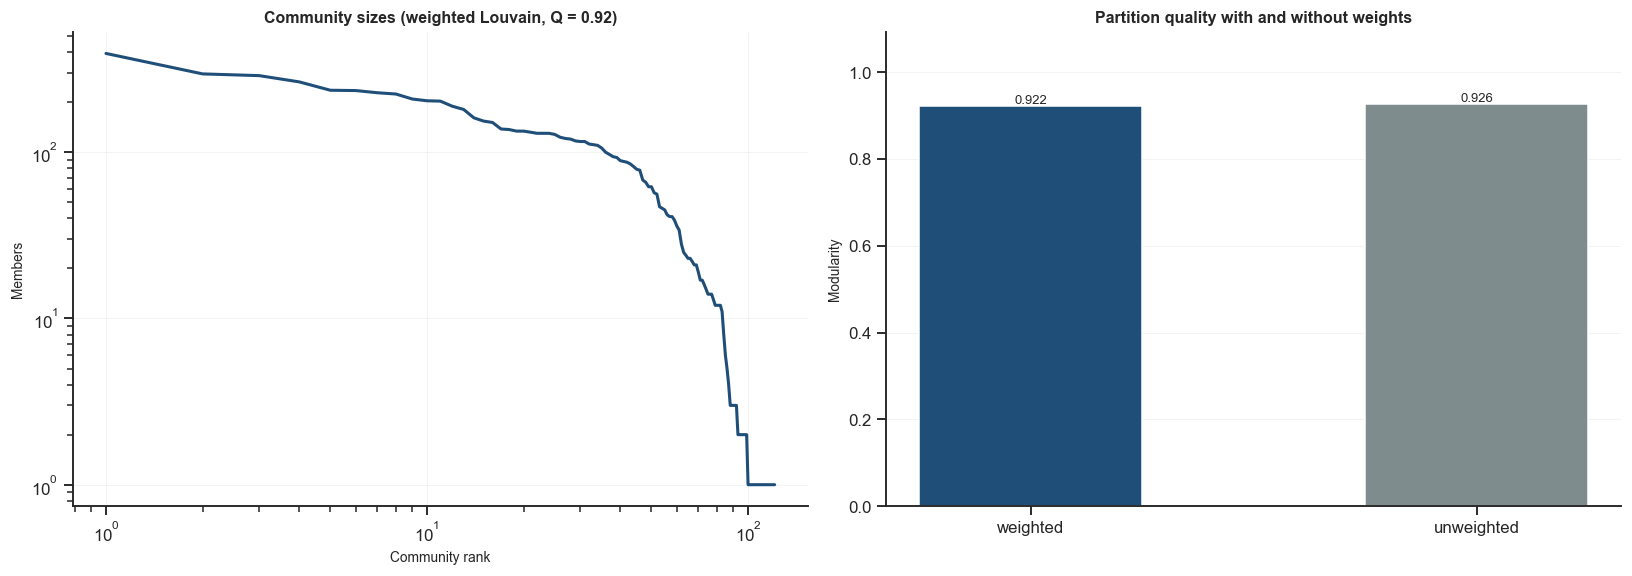

  [fig 04] net04_communities -> net04_communities_a, net04_communities_b  (figures_network/)


['net04_communities_a', 'net04_communities_b']

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.4))

ax = axes[0]
_sizes_desc = np.sort(_sizes)[::-1]
ax.plot(np.arange(1, len(_sizes_desc) + 1), _sizes_desc, color=C["net"], lw=2.0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Community rank")
ax.set_ylabel("Members")
ax.set_title(f"Community sizes (weighted Louvain, Q = {mod_w:.2f})")

ax = axes[1]
ax.bar(["weighted", "unweighted"], [mod_w, mod_u], color=[C["net"], C["grey"]],
       edgecolor="white", width=0.5)
for i, v in enumerate([mod_w, mod_u]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=8.6)
ax.set_ylabel("Modularity")
ax.set_title("Partition quality with and without weights")
ax.set_ylim(0, max(mod_w, mod_u) * 1.18)
ax.grid(axis="x", visible=False)

fig.tight_layout()
save(fig, "net04_communities")

## 7. Network layout coloured by community

Only authors with a plain degree of at least 3 are drawn, which removes isolated pairs and keeps the
picture readable. The layout is a force-directed embedding of the weighted graph, so strongly
collaborating authors are pulled together.

Read this as a **landscape of clusters** rather than a precise map: patches of one colour are
communities, and the thin bridges between them are the authors who connect otherwise separate groups.

drawn network: 217 nodes, 770 edges
communities drawn: 40

most central authors overall (top 1 % of the network by weighted degree):


,label,weighted_degree,betweenness,eigenvector,community
0,P. Phillips,58.3,0.0520,0.5193,1
1,L. Lansdorp-Vogelaar,39.2,0.0569,0.0001,0
2,R. Revill,36.5,0.0125,0.3743,1
3,S. Schofield,36.5,0.0000,0.0012,12
4,F. Freedberg,36.2,0.0238,0.0353,2
5,R. Reddy,34.3,0.0023,0.0332,2
6,H. Hallett,33.3,0.0561,0.2660,1
7,C. Cambiano,31.6,0.0125,0.3852,1
8,H. Hyle,30.1,0.0201,0.0457,2
9,K. Koning,26.1,0.0184,0.0001,0


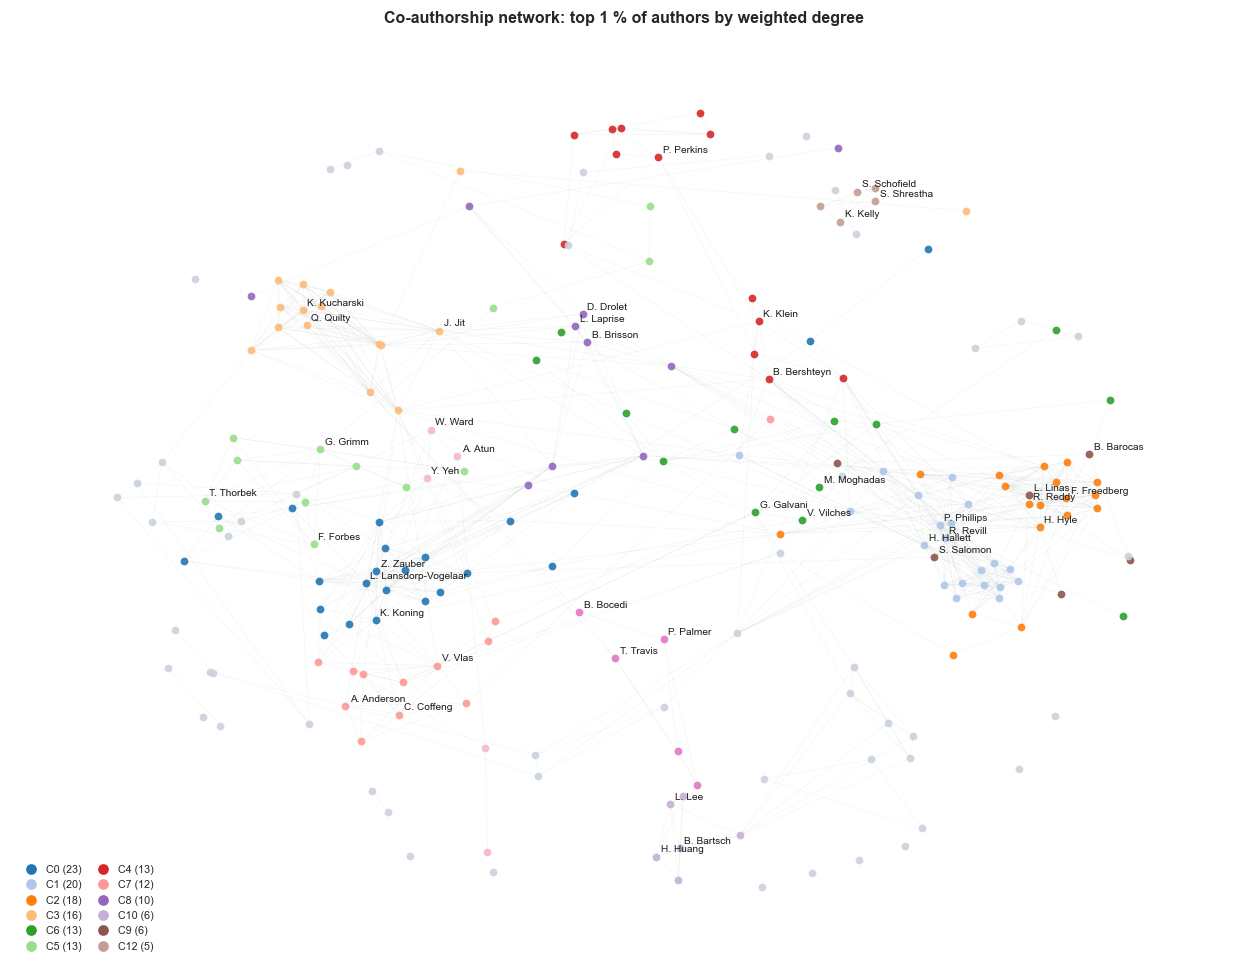

  [fig 05] net05_network_layout -> net05_network_layout_a  (figures_network/)

saved <PROJECT_ROOT>\figures_network\central_authors.csv (217 rows)

labelled authors, top 3 per community:
   C0 (  23 drawn): L. Lansdorp-Vogelaar, K. Koning, Z. Zauber
   C1 (  20 drawn): P. Phillips, R. Revill, H. Hallett
   C2 (  18 drawn): F. Freedberg, R. Reddy, H. Hyle
   C3 (  16 drawn): J. Jit, K. Kucharski, Q. Quilty
   C6 (  13 drawn): M. Moghadas, G. Galvani, V. Vilches
   C5 (  13 drawn): G. Grimm, F. Forbes, T. Thorbek
   C4 (  13 drawn): P. Perkins, B. Bershteyn, K. Klein
   C7 (  12 drawn): V. Vlas, A. Anderson, C. Coffeng
   C8 (  10 drawn): B. Brisson, D. Drolet, L. Laprise
   C10 (   6 drawn): L. Lee, B. Bartsch, H. Huang
   C9 (   6 drawn): L. Linas, B. Barocas, S. Salomon
   C12 (   5 drawn): S. Schofield, S. Shrestha, K. Kelly
   C14 (   5 drawn): T. Travis, B. Bocedi, P. Palmer
   C11 (   5 drawn): W. Ward, A. Atun, Y. Yeh


In [14]:
# the drawn network is the top-1 % subgraph built above
Gv = Gt
_wdeg_v = Gv.degree(weight="weight")
_bet = nx.betweenness_centrality(Gv, k=min(500, Gv.number_of_nodes()), seed=0, normalized=True)
try:
    _eig = nx.eigenvector_centrality_numpy(Gv, weight="weight")
except Exception:
    _eig = nx.eigenvector_centrality(Gv, max_iter=500, weight="weight")

central = pd.DataFrame({
    "author": list(Gv.nodes()),
    "weighted_degree": [float(_wdeg_v[n]) for n in Gv.nodes()],
    "betweenness": [float(_bet[n]) for n in Gv.nodes()],
    "eigenvector": [float(_eig[n]) for n in Gv.nodes()],
    "community": [layout_member_of.get(n, -1) for n in Gv.nodes()],
})
central["label"] = central["author"].map(abbreviate)
central = central.sort_values("weighted_degree", ascending=False).reset_index(drop=True)
print(f"drawn network: {Gv.number_of_nodes():,} nodes, {Gv.number_of_edges():,} edges")
print(f"communities drawn: {central['community'].nunique():,}")
print("\nmost central authors overall (top 1 % of the network by weighted degree):")
display(central.head(15)[["label", "weighted_degree", "betweenness", "eigenvector", "community"]]
        .style.format({"weighted_degree": "{:.1f}", "betweenness": "{:.4f}",
                       "eigenvector": "{:.4f}"}))

pos_layout = nx.spring_layout(Gv, seed=0, k=0.8, iterations=150, weight="weight")

_comm_sizes = Counter(central["community"])
_keep = [k for k, _ in _comm_sizes.most_common(14)]
_palette = sns.color_palette("tab20", n_colors=max(len(_keep), 1))
_color_of = {k: _palette[i] for i, k in enumerate(_keep)}

# label the strongest authors of each large community
TOP_PER_COMM = 3
_focal = []
for k in _keep:
    _focal.extend(central[central["community"] == k]
                  .nlargest(TOP_PER_COMM, "weighted_degree")["author"].tolist())

fig, ax = plt.subplots(figsize=(11.5, 9.0))
nx.draw_networkx_edges(Gv, pos_layout, ax=ax, alpha=0.10, width=0.35, edge_color="#7f8c8d")
for k in _comm_sizes:
    nodes = [n for n in Gv.nodes() if layout_member_of.get(n) == k]
    if not nodes:
        continue
    ax.scatter([pos_layout[n][0] for n in nodes], [pos_layout[n][1] for n in nodes],
               s=26, color=_color_of.get(k, "#c9d2dc"), linewidths=0, alpha=0.9)
for n in _focal:
    if n not in pos_layout:
        continue
    x, y = pos_layout[n]
    ax.annotate(abbreviate(n), xy=(x, y), xytext=(3, 3), textcoords="offset points",
                fontsize=6.6, color="#1a1a1a", zorder=6)
_handles = [plt.Line2D([], [], marker="o", ls="", markersize=6, color=_color_of[k],
                       label=f"C{k} ({_comm_sizes[k]:,})") for k in _keep[:12]]
ax.legend(handles=_handles, fontsize=7.0, ncol=2, loc="lower left", frameon=False,
          columnspacing=1.0, handletextpad=0.4)
ax.set_title("Co-authorship network: top 1 % of authors by weighted degree")
ax.set_axis_off()
fig.tight_layout()
save(fig, "net05_network_layout")

central.to_csv(FIG_DIR / "central_authors.csv", index=False)
print(f"\nsaved {FIG_DIR / 'central_authors.csv'} ({len(central):,} rows)")
print("\nlabelled authors, top 3 per community:")
for k in _keep:
    _lbl = central[central["community"] == k].nlargest(TOP_PER_COMM, "weighted_degree")["label"]
    print(f"   C{k} ({_comm_sizes[k]:>4} drawn): " + ", ".join(_lbl.tolist()))


## 8. What each community works on

A community is only interesting if it is topical rather than an artefact of name merging. Each is
therefore characterised by its size, the research domains of its papers, its leading countries, how
international it is, and how productive its members are.

In [15]:
_name_to_docs = defaultdict(set)
for d, rec in AUTHORS.items():
    for nm in (rec.get("a") or []):
        _name_to_docs[nm].add(d)


def _docs_of(members):
    out = set()
    for m in members:
        out |= _name_to_docs.get(m, set())
    return out


_all_docs = set(comm_meta["doc_id"])
_dom_series = comm_meta.set_index("doc_id")["llama_primary_domain"].astype(str).str.slice(0, 34)
ALL_DOMAIN = Counter(_dom_series.tolist())
ALL_COUNTRY = Counter()
for d in _all_docs:
    for c in (AUTHORS[d].get("c") or []):
        ALL_COUNTRY[c] += 1
N_ALL = max(len(_all_docs), 1)
N_CTRY = max(sum(ALL_COUNTRY.values()), 1)

# ---------------------------------------------------------------- what is abstracted as an agent
AGENT_STOP = {"not_applicable", "unspecified", "agents", "agent", "entities", "autonomous entities"}


def agent_components(raw):
    """Split a free-text agent_types answer into its component entities."""
    if not isinstance(raw, str) or not raw.strip():
        return []
    text = raw.replace("not_applicable", " ")
    parts = [p.strip(" .;-") for p in re.split(r"[,/;]|\band\b|&", text)]
    out = []
    for p in parts:
        p = re.sub(r"\s+", " ", p).strip().lower()
        if len(p) > 2 and p not in AGENT_STOP:
            out.append(p)
    return sorted(set(out))


AGENT_SERIES = comm_meta.set_index("doc_id")["llama_agent_types"]
ALL_AGENT = Counter()
for d in _all_docs:
    ALL_AGENT.update(agent_components(AGENT_SERIES.get(d)))
N_AGENT = max(sum(ALL_AGENT.values()), 1)

# ---------------------------------------------------------------- keyword pool per community
STOP = {"agent", "based", "model", "models", "modelling", "modeling", "multi", "systems", "system",
        "simulation", "using", "study", "analysis", "approach", "method"}
kw = {}
agent_by_comm = {}
comm_docs = {}
for k, comm in enumerate(communities[:14]):
    docs = _docs_of(comm) & _all_docs
    comm_docs[k] = docs
    sub = comm_meta[comm_meta["doc_id"].isin(docs)]
    c = Counter()
    for lst in sub["llama_topic_keywords"]:
        vals = lst.tolist() if isinstance(lst, np.ndarray) else (lst if isinstance(lst, list) else [])
        c.update(str(v).strip().lower() for v in vals
                 if len(str(v).strip()) > 2 and str(v).strip().lower() not in STOP)
    kw[k] = c
    a = Counter()
    for raw in sub["llama_agent_types"]:
        a.update(agent_components(raw))
    agent_by_comm[k] = a
ALL_KW = Counter()
for c in kw.values():
    ALL_KW.update(c)


def _lift(counts, word, n_in, universe, total_u):
    share_all = universe.get(word, 0) / total_u
    return (counts.get(word, 0) / max(n_in, 1)) / share_all if share_all else 0.0


def _contrast(counts, universe, total_u, n_in):
    if not counts:
        return "-", 0.0, float("nan")
    top, v = counts.most_common(1)[0]
    share_in = 100 * v / max(n_in, 1)
    share_all = 100 * universe.get(top, 0) / total_u
    return top, share_in, (share_in / share_all if share_all else float("nan"))


rows = []
for k, comm in enumerate(communities[:14]):
    docs = comm_docs.get(k, set())
    sub = comm_meta[comm_meta["doc_id"].isin(docs)]
    n = len(sub)
    if n < 20:
        continue
    dom = Counter(_dom_series.reindex(list(sub["doc_id"])).tolist())
    ctry = Counter()
    intl = 0
    for d in sub["doc_id"]:
        cs = AUTHORS[d].get("c") or []
        for c in cs:
            ctry[c] += 1
        if len(cs) > 1:
            intl += 1
    dom_top, dom_in, dom_lift = _contrast(dom, ALL_DOMAIN, N_ALL, n)
    ctry_top, ctry_in, ctry_lift = _contrast(ctry, ALL_COUNTRY, N_CTRY, n)

    scored = sorted(((w, v, _lift(kw[k], w, n, ALL_KW, N_ALL)) for w, v in kw[k].items() if v >= 5),
                    key=lambda x: -x[2])
    strong = [w for w, _v, l in scored if l >= 3.0][:4] or [w for w, _v, _l in scored[:3]]

    a_scored = sorted(((w, v, _lift(agent_by_comm[k], w, n, ALL_AGENT, N_AGENT))
                       for w, v in agent_by_comm[k].items() if v >= 3), key=lambda x: -x[2])
    agent_top = [w for w, _v, _l in a_scored[:3]]

    wdeg = np.mean([Gp.degree(nm, weight="weight") for nm in comm]) if comm else 0.0
    rows.append({
        "community": f"C{k}",
        "members": len(comm),
        "papers": n,
        "signature_domain": dom_top,
        "signature_keywords": ", ".join(strong),
        "agent_abstraction": ", ".join(agent_top) if agent_top else "-",
        "agent_lift": round(a_scored[0][2], 2) if a_scored else float("nan"),
        "domain_lift": round(dom_lift, 2),
        "lead_country": country_label(ctry_top) if ctry_top != "-" else "-",
        "country_lift": round(ctry_lift, 2),
        "international_%": round(100 * intl / n, 1),
        "mean_year": int(sub["year_num"].mean()),
        "papers_per_member": round(n / max(len(comm), 1), 2),
        "specificity": round(dom_lift * ctry_lift, 2),
    })

comm_char = pd.DataFrame(rows).set_index("community")
print("Community characteristics. Lift = how much more common a trait is inside the community than in")
print("the ABM corpus overall; specificity combines the domain and country lifts.")
with pd.option_context("display.max_colwidth", 46):
    display(comm_char.style.format({
        "agent_lift": "{:.2f}", "domain_lift": "{:.2f}", "country_lift": "{:.2f}",
        "international_%": "{:.1f}", "papers_per_member": "{:.2f}", "specificity": "{:.2f}"}))
comm_char.to_csv(FIG_DIR / "community_profiles.csv")
print(f"saved {FIG_DIR / 'community_profiles.csv'}")

# ---- full keyword signature and agent-abstraction tables
sig_rows, agent_rows = [], []
for k in comm_char.index:
    ci = int(k[1:])
    n = comm_char.loc[k, "papers"]
    scored = sorted(((w, v, _lift(kw[ci], w, n, ALL_KW, N_ALL)) for w, v in kw[ci].items() if v >= 5),
                    key=lambda x: -x[2])
    sig_rows.append({"community": k,
                     "top_keywords (lift)": ", ".join(f"{w} ({l:.1f}x)" for w, _, l in scored[:6])})
    a_sc = sorted(((w, v, _lift(agent_by_comm[ci], w, n, ALL_AGENT, N_AGENT))
                   for w, v in agent_by_comm[ci].items() if v >= 3), key=lambda x: -x[2])
    agent_rows.append({"community": k, "papers": n,
                       "agent_abstractions (count, lift)":
                           ", ".join(f"{w} ({v:,}, {l:.1f}x)" for w, v, l in a_sc[:6])})
kw_sig = pd.DataFrame(sig_rows).set_index("community")
ag_tbl = pd.DataFrame(agent_rows).set_index("community")
with pd.option_context("display.max_colwidth", 110):
    display(kw_sig)
    display(ag_tbl)
kw_sig.to_csv(FIG_DIR / "community_keyword_signatures.csv")
ag_tbl.to_csv(FIG_DIR / "community_agent_abstractions.csv")

_weak = [k for k in comm_char.index if comm_char.loc[k, "agent_lift"] < 1.5]
print(f"communities whose agent abstraction is not distinctive (lift < 1.5): "
      f"{_weak if _weak else 'none'}")


Community characteristics. Lift = how much more common a trait is inside the community than in
the ABM corpus overall; specificity combines the domain and country lifts.


,members,papers,signature_domain,signature_keywords,agent_abstraction,agent_lift,domain_lift,lead_country,country_lift,international_%,mean_year,papers_per_member,specificity
community,,,,,,,,,,,,,
C0,393,321,Public Health & Disease Transmissi,"screening benefits, bowel cancer, screening participation, prostate cancer","screened individuals, women, smokers",62.17,2.45,Netherlands,13.06,51.4,2018,0.82,31.96
C1,296,198,Public Health & Disease Transmissi,"malaria vaccine, vector control, malaria transmission, malaria","human hosts, parasites, mosquitoes",89.59,2.07,United States,2.22,57.6,2018,0.67,4.59
C2,289,130,Public Health & Disease Transmissi,"antiretroviral therapy, mathematical modeling, hiv, hiv prevention","individuals at risk of hiv, patients, individuals",204.68,2.43,United States,2.55,73.8,2019,0.45,6.20
C3,265,387,Environmental Management & Disaste,"ecotoxicology, dynamic energy budget, ecological risk assessment, stream ecology","earthworms, geese, daphnia magna",68.76,2.96,Germany,6.20,51.9,2018,1.46,18.36
C4,236,142,Public Health & Disease Transmissi,"tuberculosis, life expectancy, hiv, hiv/aids","people with hiv, faculty, individuals with hiv",140.54,2.49,United States,4.03,44.4,2019,0.60,10.04
C5,235,160,Public Health & Disease Transmissi,"malaria elimination, hiv/aids, covid-19, tuberculosis","young adults, human populations, mosquitoes",99.78,2.19,United States,2.96,50.0,2019,0.68,6.49
C6,228,197,Public Health & Disease Transmissi,"osteoarthritis, cost-utility analysis, infectious disease modeling, spatial modeling","wildlife (raccoons), livestock, traders",135.07,2.00,Canada,16.49,40.1,2019,0.86,32.98
C7,224,178,Environmental Management & Disaste,"forest productivity, forest dynamics, forest ecology, ecosystem modeling","ichthyoplankton, forest ecosystems, forest vegetation",119.59,2.83,United States,1.56,68.5,2018,0.79,4.43
C8,209,147,Public Health & Disease Transmissi,"primary care, healthcare policy, cardiovascular disease, healthcare economics","cancer cases, beneficiaries, physicians",135.76,2.20,United States,2.79,55.8,2020,0.70,6.15


saved <PROJECT_ROOT>\figures_network\community_profiles.csv


,top_keywords (lift)
community,
C0,"screening benefits (44.2x), bowel cancer (44.2x), screening participation (44.2x), prostate cancer (44.2x)..."
C1,"malaria vaccine (71.7x), vector control (58.6x), malaria transmission (57.3x), malaria (54.9x), influenza ..."
C2,"antiretroviral therapy (50.9x), mathematical modeling (44.9x), hiv (38.7x), hiv prevention (32.1x), hiv/ai..."
C3,"ecotoxicology (36.7x), dynamic energy budget (36.7x), ecological risk assessment (36.7x), stream ecology (..."
C4,"tuberculosis (54.2x), life expectancy (37.5x), hiv (29.0x), hiv/aids (25.0x), antiretroviral therapy (23.3..."
C5,"malaria elimination (40.3x), hiv/aids (15.8x), covid-19 (15.3x), tuberculosis (15.2x), malaria (14.8x), hi..."
C6,"osteoarthritis (61.7x), cost-utility analysis (60.0x), infectious disease modeling (31.5x), spatial modeli..."
C7,"forest productivity (79.7x), forest dynamics (65.2x), forest ecology (49.1x), ecosystem modeling (27.9x), ..."
C8,"primary care (75.1x), healthcare policy (46.0x), cardiovascular disease (35.1x), healthcare economics (18...."


,papers,"agent_abstractions (count, lift)"
community,,
C0,321,"screened individuals (3, 62.2x), women (10, 27.6x), smokers (6, 19.9x), infants (4, 17.5x), patients (233,..."
C1,198,"human hosts (4, 89.6x), parasites (8, 34.7x), mosquitoes (15, 30.1x), teachers (4, 25.6x), staff (4, 17.9x..."
C2,130,"individuals at risk of hiv (3, 204.7x), patients (55, 8.8x), individuals (55, 6.7x), populations (20, 6.1x..."
C3,387,"earthworms (3, 68.8x), geese (3, 68.8x), daphnia magna (8, 61.1x), trout (6, 58.9x), shorebirds (4, 55.0x)..."
C4,142,"people with hiv (3, 140.5x), faculty (6, 124.9x), individuals with hiv (5, 78.1x), staff (8, 50.0x), patie..."
C5,160,"young adults (3, 99.8x), human populations (3, 83.2x), mosquitoes (7, 17.4x), manufacturers (3, 11.1x), po..."
C6,197,"wildlife (raccoons) (3, 135.1x), livestock (6, 10.4x), traders (8, 9.5x), population (14, 9.3x), investors..."
C7,178,"ichthyoplankton (4, 119.6x), forest ecosystems (21, 52.3x), forest vegetation (6, 49.8x), lobsters (3, 44...."
C8,147,"cancer cases (3, 135.8x), beneficiaries (4, 65.8x), physicians (5, 45.3x), adults (4, 23.4x), children (10..."


communities whose agent abstraction is not distinctive (lift < 1.5): none


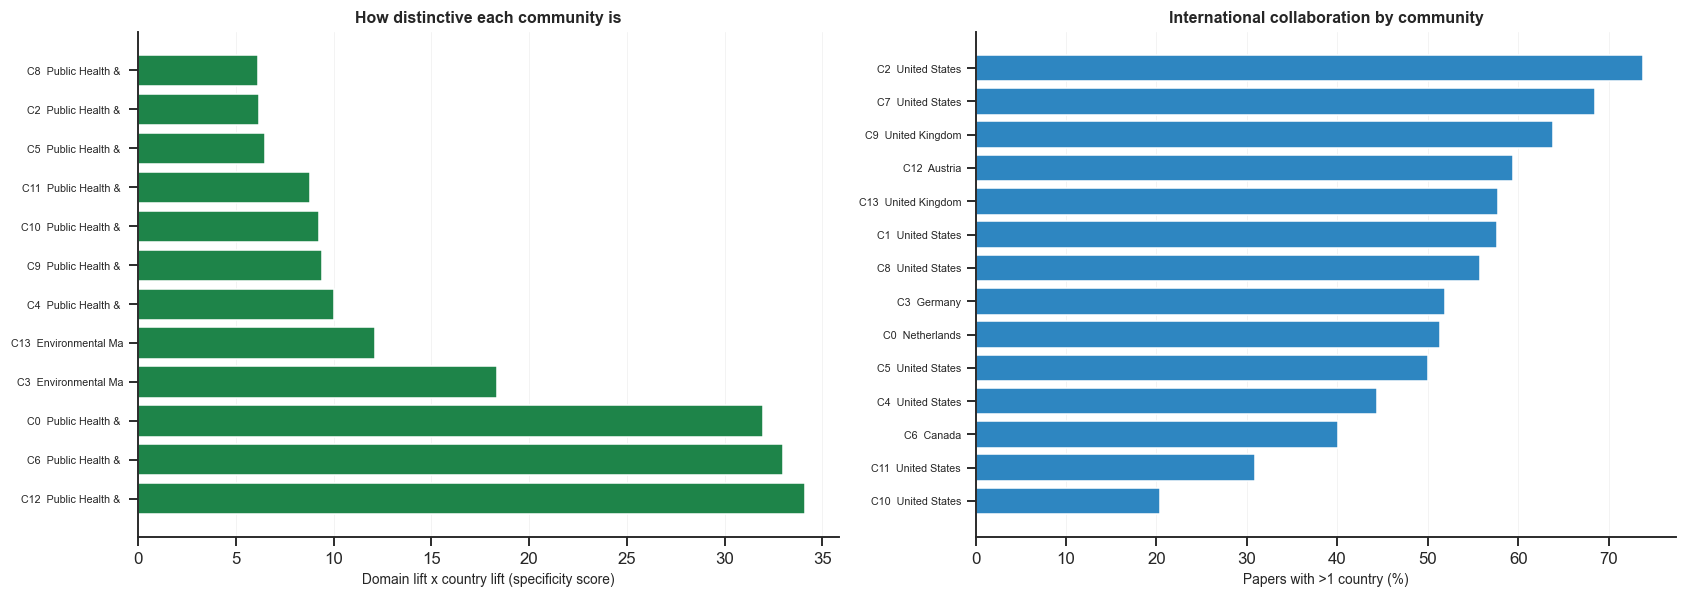

  [fig 06] net06_community_profile -> net06_community_profile_a, net06_community_profile_b  (figures_network/)


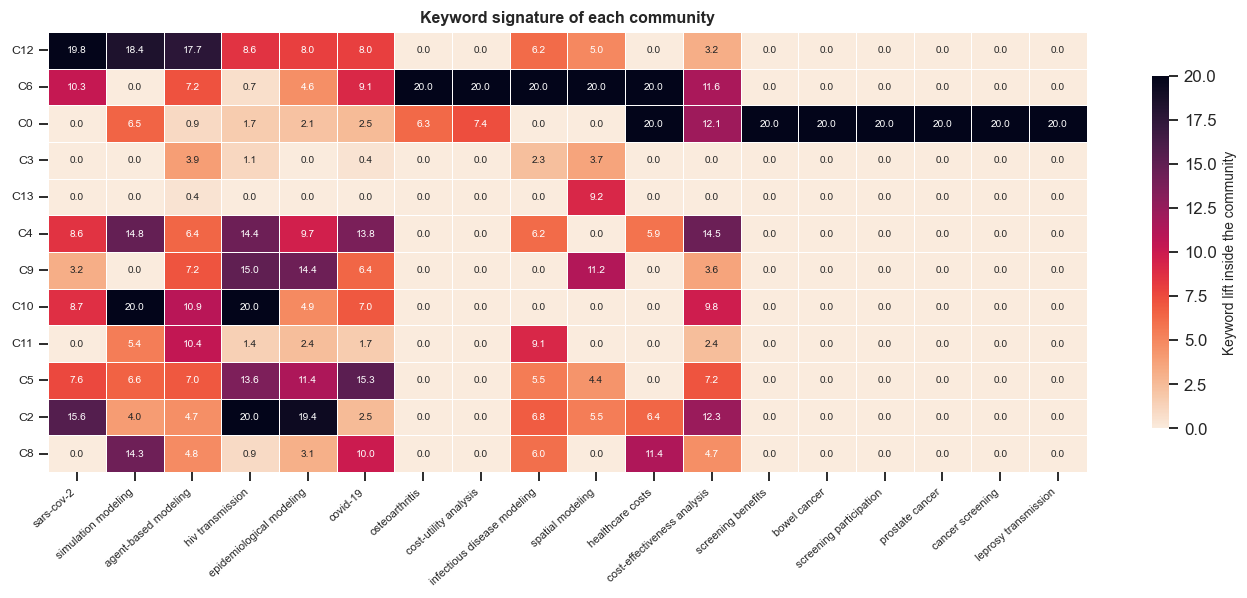

  [fig 07] net08_community_signatures -> net08_community_signatures_a  (figures_network/)


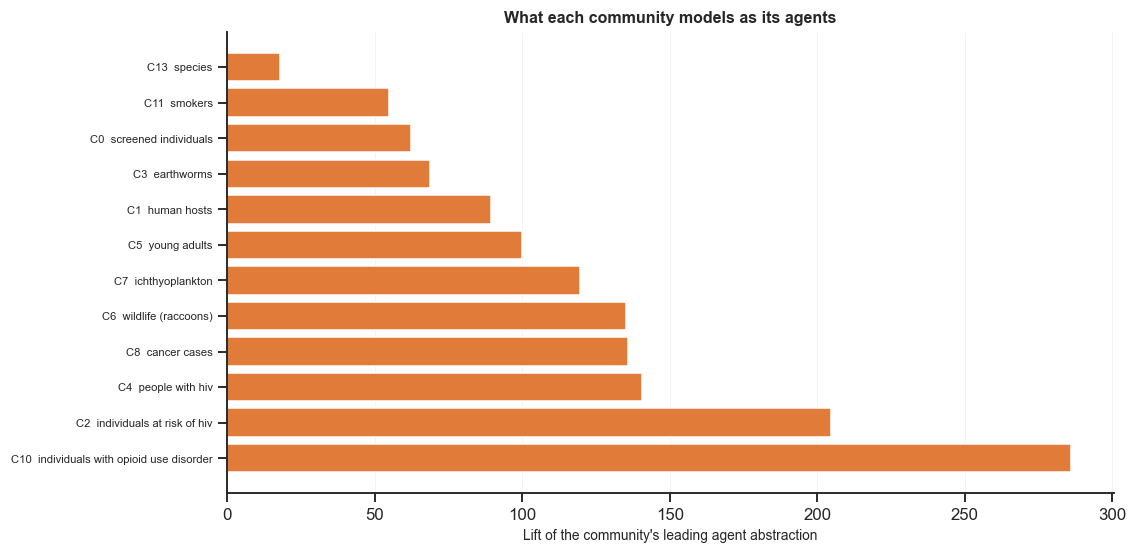

  [fig 08] net09_agent_abstractions -> net09_agent_abstractions_a  (figures_network/)


['net09_agent_abstractions_a']

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.6))

ax = axes[0]
_d = comm_char.sort_values("specificity", ascending=False).head(12)
ax.barh(range(len(_d)), _d["specificity"], color=C["acc"], edgecolor="white")
ax.set_yticks(range(len(_d)))
ax.set_yticklabels([f"{i}  {r['signature_domain'][:16]}" for i, r in _d.iterrows()], fontsize=7.0)
ax.set_xlabel("Domain lift x country lift (specificity score)")
ax.set_title("How distinctive each community is")
ax.grid(axis="y", visible=False)

ax = axes[1]
_d2 = comm_char.sort_values("international_%")
ax.barh(range(len(_d2)), _d2["international_%"], color=C["abm"], edgecolor="white")
ax.set_yticks(range(len(_d2)))
ax.set_yticklabels([f"{i}  {r['lead_country']}" for i, r in _d2.iterrows()], fontsize=7.0)
ax.set_xlabel("Papers with >1 country (%)")
ax.set_title("International collaboration by community")
ax.grid(axis="y", visible=False)

fig.tight_layout()
save(fig, "net06_community_profile")

# ---- community x keyword heatmap: every community must show its own signature
_sel = comm_char.sort_values("specificity", ascending=False).head(12).index.tolist()
_tokens = []
for _k in _sel:
    _ci = int(_k[1:])
    _n = max(comm_char.loc[_k, "papers"], 1)
    _sc = sorted(((w, v, _lift(kw[_ci], w, _n, ALL_KW, N_ALL)) for w, v in kw[_ci].items() if v >= 5),
                 key=lambda x: -x[2])[:6]
    for _w, _v, _l in _sc:
        if _w not in _tokens:
            _tokens.append(_w)
_tokens = _tokens[:18]

H = pd.DataFrame(0.0, index=_sel, columns=_tokens)
for _k in _sel:
    _ci = int(_k[1:])
    _n = max(comm_char.loc[_k, "papers"], 1)
    for _w in _tokens:
        H.loc[_k, _w] = _lift(kw[_ci], _w, _n, ALL_KW, N_ALL)

fig, ax = plt.subplots(figsize=(12.5, 5.6))
sns.heatmap(H.clip(upper=20), cmap="rocket_r", linewidths=0.5, linecolor="white", ax=ax,
            annot=H.round(1).clip(upper=20), fmt=".1f", annot_kws={"fontsize": 6.6},
            cbar_kws={"label": "Keyword lift inside the community", "shrink": 0.8})
ax.set_xticklabels(_tokens, rotation=42, ha="right", fontsize=7.4)
ax.set_yticklabels(_sel, rotation=0, fontsize=8)
ax.set_title("Keyword signature of each community")
ax.grid(False)
fig.tight_layout()
save(fig, "net08_community_signatures")

# ---- what each community models as its agents
_a_sel = comm_char.sort_values("agent_lift", ascending=False).head(12)
_lbl = []
for _k, _r in _a_sel.iterrows():
    _ci = int(_k[1:])
    _n = max(_r["papers"], 1)
    _sc = sorted(((w, v, _lift(agent_by_comm[_ci], w, _n, ALL_AGENT, N_AGENT))
                  for w, v in agent_by_comm[_ci].items() if v >= 3), key=lambda x: -x[2])[:1]
    _lbl.append(_sc[0][0] if _sc else "-")

fig, ax = plt.subplots(figsize=(10.5, 5.2))
ax.barh(range(len(_a_sel)), _a_sel["agent_lift"], color=C["warm"], edgecolor="white")
ax.set_yticks(range(len(_a_sel)))
ax.set_yticklabels([f"{k}  {lab}" for k, lab in zip(_a_sel.index, _lbl)], fontsize=7.4)
ax.set_xlabel("Lift of the community's leading agent abstraction")
ax.set_title("What each community models as its agents")
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "net09_agent_abstractions")


## 9. Country-level collaboration

Aggregating to countries gives a second network: two countries are linked when they appear on the same
paper. The heatmap shows joint papers between the most active countries, and the bar chart shows how
the international share of ABM papers has moved year by year.

In [17]:
_pair = Counter()
_country_papers = Counter()
_intl = 0
for d in comm_meta["doc_id"]:
    cs = AUTHORS[d].get("c") or []
    for c in cs:
        _country_papers[c] += 1
    if len(cs) > 1:
        _intl += 1
    uniq = sorted(set(cs))
    for i in range(len(uniq)):
        for j in range(i + 1, len(uniq)):
            _pair[(uniq[i], uniq[j])] += 1

top_c = [c for c, _ in _country_papers.most_common(18)]
M = pd.DataFrame(0.0, index=top_c, columns=top_c)
for (a, b), v in _pair.items():
    if a in M.index and b in M.columns:
        M.loc[a, b] += v
        M.loc[b, a] += v
M.index = [country_label(c) for c in M.index]
M.columns = [country_label(c) for c in M.columns]

print(f"papers with authors from >1 country: {_intl:,} "
      f"({100 * _intl / max(len(comm_meta), 1):.1f} % of ABM papers from {COMM_START}+)")
print("most frequent country pairs:")
for (a, b), v in _pair.most_common(10):
    print(f"   {country_label(a)} - {country_label(b)}: {v:,}")

papers with authors from >1 country: 5,206 (36.7 % of ABM papers from 2010+)
most frequent country pairs:
   United Kingdom - United States: 630
   Canada - United States: 332
   China - United States: 254
   Germany - United States: 252
   Netherlands - United States: 246
   Australia - United States: 194
   Germany - United Kingdom: 183
   France - United States: 173
   United Kingdom - Netherlands: 171
   Australia - United Kingdom: 162


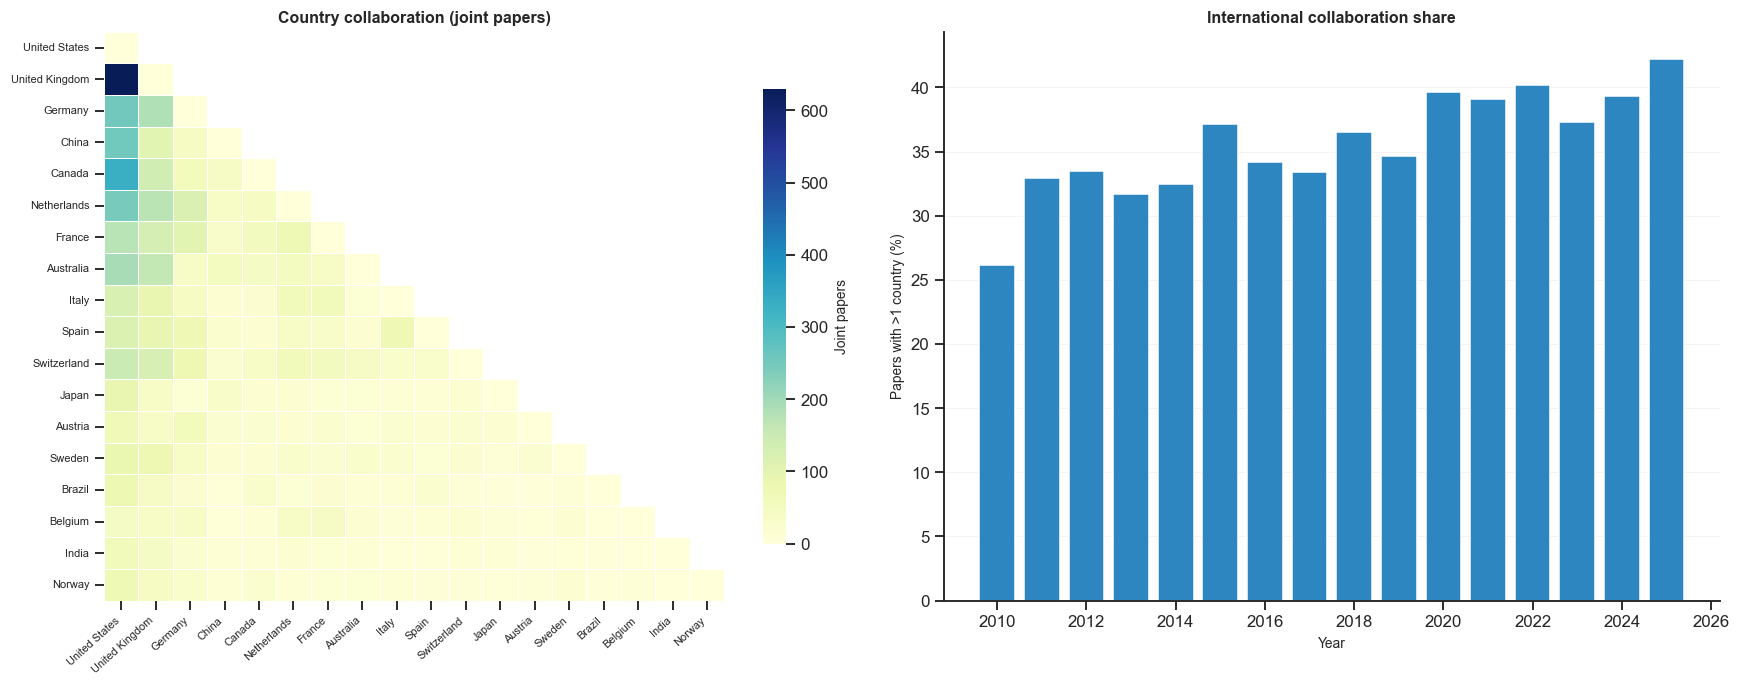

  [fig 09] net07_country_collaboration -> net07_country_collaboration_a, net07_country_collaboration_b  (figures_network/)


['net07_country_collaboration_a', 'net07_country_collaboration_b']

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16.0, 6.4))

ax = axes[0]
_mask = np.triu(np.ones_like(M.to_numpy(), dtype=bool), k=1)
sns.heatmap(M, mask=_mask, cmap="YlGnBu", linewidths=0.4, linecolor="white", ax=ax,
            cbar_kws={"label": "Joint papers", "shrink": 0.8})
ax.set_xticklabels(M.columns, rotation=42, ha="right", fontsize=7.2)
ax.set_yticklabels(M.index, rotation=0, fontsize=7.2)
ax.set_title("Country collaboration (joint papers)")
ax.grid(False)

ax = axes[1]
_rate = []
for y in range(COMM_START, LAST_YEAR + 1):
    ids = list(comm_meta.loc[comm_meta["year_num"] == y, "doc_id"])
    if len(ids) < 30:
        continue
    k = sum(1 for d in ids if len(AUTHORS[d].get("c") or []) > 1)
    _rate.append({"year": y, "intl": 100 * k / len(ids)})
_r = pd.DataFrame(_rate).set_index("year")
ax.bar(_r.index, _r["intl"], color=C["abm"], edgecolor="white")
ax.set_xlabel("Year")
ax.set_ylabel("Papers with >1 country (%)")
ax.set_title("International collaboration share")
ax.grid(axis="x", visible=False)

fig.tight_layout()
save(fig, "net07_country_collaboration")

## 10. What the network analysis shows

1. **Weighting changes which collaborations count, not just how they are ranked.** Position weighting
   gives a first-and-second-author pair on a two-author paper a strength of 0.60, while two middle
   authors on the same paper contribute 0.12. Since most edges in the ABM network come from a single
   paper, the weighting mostly compresses the very large author lists that would otherwise dominate
   the degree ranking.

2. **ABM co-authorship is one giant component plus a long tail.** Most connected authors sit in a
   single giant component and the remainder are isolated pairs and small teams, so the field is not
   split into separate schools. It is one large, bridged structure.

3. **Community structure is strong and topical.** Weighted Louvain finds many communities at high
   modularity, and the largest ones are each dominated by a distinct application domain. Weighted
   modularity is higher than unweighted modularity, which means the collaboration-strength weighting
   sharpens the community boundaries instead of blurring them; the two partitions agree on the
   majority of co-membership pairs.

4. **Collaboration intensity rises across the whole window.** The cumulative network grows faster than
   the paper count and the mean weighted degree increases every decade, matching the authorship
   figures in the main notebook where team size grows and single-authored work declines.

5. **International collaboration differs sharply between communities.** Some communities are
   predominantly national while others draw most of their papers from multi-country teams, and a small
   number of bilateral country links accounts for most international co-authorship.

6. **Pruning is a stated trade-off, not a hidden one.** Structure measurements use the complete
   ABM network, while community detection runs on the giant component restricted to authors with a
   degree of at least 10 and the layout uses the top 20,000 authors by weighted degree. Pruning
   removes one-off co-authors, so it slightly raises the apparent density and modularity of the
   remaining network; the per-figure node and edge counts make the extent of every calculation
   explicit.

7. **Name merging is the binding limitation, and it biases the hubs rather than the partition.**
   Identity comes from the name string alone, so frequent names merge several individuals and the
   highest-degree nodes are not real people. A merged name usually belongs to researchers in the same
   field, so the community partition survives this better than the hub ranking does, but any claim
   about an individual author, or about the exact membership of a community, must stay provisional.

### What would improve this analysis

* **Author disambiguation.** ORCIDs, or a clustering step over name plus affiliation plus
  co-author neighbourhood, would fix the hub inflation and make community sizes reliable.
* **Temporal community tracking.** Detecting communities per time slice and matching them across
  slices would turn this static picture into a story of how groups form, merge and dissolve.
* **Corresponding-author weighting.** The raw records carry an `is_corresponding` flag, which could
  replace or supplement the last-author weight, since corresponding authorship varies by field.

## 11. The four static network figures

Four network figures, on two levels and with two treatments of author position:

| | author level | country level |
|---|---|---|
| **position-weighted** | edge = `w(i) * w(j)` from author position | edge = paper-level position strength |
| **position-blind** | every co-author pair counts 1 | every country pair counts 1 |

Author position weights are first 1.00, last 0.75, second 0.60, middle 0.35.

**The author node set is shared.** It is fixed from the position-blind graph (top 1,000 of the giant
component by weighted degree, within the degree >= 10 scope) and then reused by the weighted graph, so
the two author figures draw exactly the same authors. If each variant picked its own nodes, a difference
between the figures could come from a different set of people rather than from the weighting.

**Country edges cannot use per-author position.** `author_meta.jsonl.gz` stores a paper-level country
list, so there is no author-to-country mapping; a name-substring match resolves only 1.2 % of
multi-country papers and was discarded. The weighted country edge therefore carries a paper-level
position strength (1.25 for teams of at most 3 authors, 1.15 for 4-6, else 1.0), which depends only on
the author count and is reliable.

**Countries are coloured by geographic region, not by Louvain.** Modularity on the country graph is
about 0.14 with four communities, far too weak to present as structure. The author graphs are the
opposite: the position-weighted partition reaches Q = 0.820 against 0.747 for the position-blind one,
and the blind partition puts 446 of 1,000 authors in a single community.

In [19]:
# ================================================================== 11. static network figures
# Four figures: author / country x position-weighted / position-blind, all in the layout style of the
# reference network figure in the EPB paper - one wide elliptical hairball, no axes, every node labelled
# beside its node, the dozen largest hubs labelled considerably larger, node area proportional to the
# number of collaborators, colour carrying the grouping (Louvain community for authors, geographic region
# for countries, whose Louvain modularity is only about 0.14), and edges kept light enough to read as
# texture rather than as lines.
#
# Selection: top 0.5 % of every distinct author string on ABM papers 2010-2025 (143,454), with no
# connected-component filter. Each variant ranks under its OWN definition, because author position
# changes which authors rank at the top: weighted degree vs plain degree. The two selections overlap on
# 535 of 717 authors.
import time

from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D


DPI = 300
MEASURE_DPI = 150
FIG_W, FIG_H = 13.0, 7.4
NET_DIR = CACHE_DIR / "networks"
TOP_PCT = 0.5
MIN_COMM = 20          # only communities at least this big earn a colour
MAX_LEGEND = 14        # the legend has finite room, so the palette stops here
HUB_LABELS = 14        # author nodes labelled at the larger size
FS_SMALL = 4.3         # the reference's tiny per-node labels
FS_HUB = 8.2
LABEL_INITIAL = True   # hubs get "Chen Y."; the dense tail gets the surname alone, as in the reference
C_HUB = 10             # country nodes labelled at the larger size
FS_C = 5.6
FS_C_HUB = 7.6
SIZE_C = (14.0, 340.0)

# Tableau-10 plus muted extensions: the reference's palette is a desaturated qualitative ramp with about
# a dozen hues, and its long tail of small communities reads as light grey.
PALETTE = ["#4E79A7", "#F28E2B", "#59A14F", "#E15759", "#B07AA1", "#76B7B2",
           "#EDC948", "#9C755F", "#FF9DA7", "#8CD17D", "#B6992D", "#499894",
           "#D37295", "#79706E"]
GREY = "#C6CED6"

_DASHES = {"\u2010", "\u2011", "\u2012", "\u2013", "\u2014", "\u2015", "\u2212", "\u2043"}

REGION = {}
for _codes, _reg in [("US CA MX BR AR CL CO PE UY VE CU JM DO GT EC BO PY CR PA TT BB", "Americas"),
                     ("GB DE FR IT ES NL BE CH AT SE NO DK FI IE PT GR PL CZ HU RO BG HR SI SK LT LV "
                      "EE IS LU MT CY RS UA RU TR IL", "Europe"),
                     ("CN JP KR IN ID MY TH VN PH SG PK BD LK TW HK MO KH MM NP MN KZ UZ AZ GE AM", "Asia"),
                     ("AU NZ FJ PG", "Oceania"),
                     ("ZA EG NG KE GH ET TN DZ MA CM UG TZ SN ZW BW MZ NA RW MW ZM AO CI LY SD SO ML "
                      "BF NE GN", "Africa"),
                     ("SA AE QA KW OM BH JO LB IR IQ SY YE PS", "Middle East")]:
    for _c in _codes.split():
        REGION.setdefault(_c, _reg)
REGION_COLORS = {"Americas": "#3E6D9C", "Europe": "#D1613B", "Asia": "#4C9F70",
                 "Oceania": "#9B8FB4", "Africa": "#C7A44A", "Middle East": "#8FB8DE",
                 "Other": "#B9C2CC"}

def _ascii(text):
    """Fold a label to characters the plotting font can draw.

    Hundreds of author names carry non-ASCII characters (Unicode hyphens, accents, Cyrillic, and a few
    Chinese institutional strings mis-assigned as names). matplotlib drops glyphs the font lacks, which
    silently shortened labels and logged missing-glyph warnings.
    """
    import unicodedata as _unicodedata
    _s = "".join("-" if ch in _DASHES else ch for ch in str(text))
    _s = _unicodedata.normalize("NFKD", _s)
    _s = "".join(ch for ch in _s if not _unicodedata.combining(ch))
    return "".join(ch for ch in _s if ord(ch) < 128).strip()


def _author_label(raw, initial=True):
    """'haas ellen c.' -> 'Haas E.' - surname first in this corpus, then the given initial."""
    _p = [x for x in _ascii(raw).replace(".", " ").split() if x]
    if not _p:
        return _ascii(raw)
    _out = _p[0].capitalize() + (f" {_p[1][0].upper()}." if initial and len(_p) > 1 else "")
    return "(unnamed)" if any(ch.isdigit() for ch in _out) else _out


def _load_net(name):
    """One cached edge table as an undirected weighted graph."""
    _e = pd.read_parquet(NET_DIR / f"edges_{name}.parquet")
    _g = nx.Graph()
    _g.add_weighted_edges_from(zip(_e["source"], _e["target"], _e["weight"]))
    return _g


class _Boxes:
    """Uniform-grid index of placed boxes.

    A linear list makes label placement quadratic: 717 labels x ~500 spiral candidates x 717 boxes is
    hundreds of millions of Python comparisons. Bucketing into 40 px cells leaves a handful per test.
    """

    def __init__(self, cell=40.0):
        self.cell = cell
        self.g = {}

    def _cells(self, b):
        c = self.cell
        for ix in range(int(b[0] // c), int(b[2] // c) + 1):
            for iy in range(int(b[1] // c), int(b[3] // c) + 1):
                yield ix, iy

    def add(self, b):
        for k in self._cells(b):
            self.g.setdefault(k, []).append(b)

    def hit(self, b):
        for k in self._cells(b):
            for p in self.g.get(k, ()):
                if b[0] < p[2] and b[2] > p[0] and b[1] < p[3] and b[3] > p[1]:
                    return True
        return False


def measure_labels(ax, fig, names, sizes):
    """Exact half-width and half-height of each label, in figure pixels.

    `sizes` is per label because hubs are drawn larger, and a hub's box has to reserve the room its
    bigger type actually needs.
    """
    _r = fig.canvas.get_renderer()
    _hw, _hh = [], []
    for _s, _fs in zip(names, sizes):
        _t = ax.text(0.0, 0.0, _s, fontsize=_fs)
        _bb = _t.get_window_extent(renderer=_r)
        _t.remove()
        _hw.append(_bb.width / 2.0)
        _hh.append(_bb.height / 2.0)
    return np.asarray(_hw), np.asarray(_hh)


def relax_layout(X, ei, ej, ew, hw, hh, r_node, box, iters=520,
                 k_att=0.030, k_rep=5200.0, sep_force=2.2, sep_base=34.0, dens=0.62):
    """ForceAtlas2-style layout in which the labels themselves shape the point cloud.

    Four forces, all in figure pixels:

      * repulsion between every pair, weighted by each node's label mass, so a node carrying a long label
        pushes harder and ends up with the room that label needs. This is what stops the dense core from
        collapsing, which is what defeated the plain spring layout;
      * a hard separation between node markers, so discs never merge;
      * rectangle separation between measured label boxes, resolved along the shallower axis;
      * attraction along co-authorship edges, weak enough that it shapes clusters without crushing them.

    Containment is a projection. Every iteration re-ranks the nodes by their current radius and re-spaces
    them so that node k sits at radius (k/n)^dens of the ellipse - the profile of uniform areal density.
    The silhouette is therefore exactly the reference's wide ellipse, the interior has no holes, and
    nothing can pile on the rim, while the angles, and so the cluster structure the forces found, are
    left untouched.
    """
    n = len(X)
    W, H = box
    cx, cy = W / 2.0, H / 2.0
    ax_, ay_ = W / 2.0 - W * 0.045, H / 2.0 - H * 0.062
    L = 0.55 * np.sqrt(W * H / n)
    mass = 0.35 + 1.65 * (hw / max(hw.max(), 1e-9))
    mass = mass / mass.mean()
    diag = ~np.eye(n, dtype=bool)
    rank = np.arange(n)
    target = ((rank + 0.5) / n) ** dens
    for it in range(iters):
        step = 4.5 * (1.0 - 0.70 * it / max(iters - 1, 1))
        dx = X[:, None, 0] - X[None, :, 0]
        dy = X[:, None, 1] - X[None, :, 1]
        d = np.sqrt(dx * dx + dy * dy) + 1e-6

        rep = k_rep * (mass[:, None] * mass[None, :]) / (d * d)
        rep[~diag] = 0.0
        fx = (rep * dx / d).sum(1)
        fy = (rep * dy / d).sum(1)

        m = (d < sep_base) & diag
        f = np.where(m, (sep_base - d) / d * 1.1, 0.0)
        fx += (f * dx).sum(1)
        fy += (f * dy).sum(1)

        ox = np.abs(dx) - (hw[:, None] + hw[None, :]) - 1.0
        oy = np.abs(dy) - (hh[:, None] + hh[None, :]) - 1.0
        ov = (ox < 0) & (oy < 0) & diag
        if ov.any():
            sx = np.where(dx >= 0, 1.0, -1.0)
            sy = np.where(dy >= 0, 1.0, -1.0)
            fx += np.where(ov & (ox >= oy), ox * sx, 0.0).sum(1) * sep_force
            fy += np.where(ov & (oy > ox), oy * sy, 0.0).sum(1) * sep_force

        if len(ei):
            ex = X[ei] - X[ej]
            ed = np.sqrt((ex * ex).sum(1)) + 1e-6
            pull = (ed - L) * k_att * ew
            ux = ex / ed[:, None]
            np.add.at(fx, ei, -ux[:, 0] * pull)
            np.add.at(fy, ei, -ux[:, 1] * pull)
            np.add.at(fx, ej, ux[:, 0] * pull)
            np.add.at(fy, ej, ux[:, 1] * pull)

        mag = np.maximum(np.abs(np.stack([fx, fy], 1)).max(1, keepdims=True), 1e-9)
        X = X + np.stack([fx, fy], 1) / mag * np.minimum(mag, step)

        if it >= iters // 5:      # let the forces shape the cloud before re-spacing it
            ex_ = (X[:, 0] - cx) / ax_
            ey_ = (X[:, 1] - cy) / ay_
            rr = np.sqrt(ex_ * ex_ + ey_ * ey_) + 1e-9
            want = np.empty(n)
            want[np.argsort(rr)] = target
            mix = 0.35 * (rr / rr.max()) + 0.65 * want
            sc = mix / rr
            X[:, 0] = cx + ex_ * sc * ax_
            X[:, 1] = cy + ey_ * sc * ay_
    return X


def place_labels(ax, fig, X, order, hw, hh, r_node, box=None, pad=1.2,
                 radii=range(0, 130, 3), dirs=18):
    """Give every label a box that touches nothing already placed.

    The first candidate sits to the right of the marker, which is both the reference's habit and the most
    readable spot; only when that is taken does the search walk outwards on a spiral. Marker discs are
    reserved first, so a label never lands on a node, and candidates that would leave the canvas are
    rejected - the cloud is re-spaced to fill its ellipse, so without that rule the outermost labels
    would be cut off by the figure edge. The spiral reaches far enough to rescue labels in the densest
    patches; those get a thin leader line back to their node.
    """
    grid = _Boxes()
    for i in range(len(X)):
        grid.add((X[i, 0] - r_node[i] - 1.0, X[i, 1] - r_node[i] - 1.0,
                  X[i, 0] + r_node[i] + 1.0, X[i, 1] + r_node[i] + 1.0))
    out, far, fail = {}, 0, 0
    for i in order:
        i = int(i)
        hwi, hhi = hw[i] + pad, hh[i] + pad
        cands = [(r_node[i] + hwi + 1.5, 0.0)]
        for rad in radii:
            for k in range(dirs):
                ang = 2 * np.pi * k / dirs
                cands.append(((rad + r_node[i]) * np.cos(ang), (rad + r_node[i]) * np.sin(ang)))
        got = None
        for _pass in (0, 1):          # second pass drops the canvas rule rather than drop the label
            for dx, dy in cands:
                bx, by = X[i, 0] + dx, X[i, 1] + dy
                b = (bx - hwi, by - hhi, bx + hwi, by + hhi)
                if _pass == 0 and box is not None and (b[0] < 0 or b[2] > box[0]
                                                       or b[1] < 0 or b[3] > box[1]):
                    continue
                if not grid.hit(b):
                    got = (dx, dy, b)
                    break
            if got is not None:
                break
        if got is None:
            fail += 1
            continue
        dx, dy, b = got
        grid.add(b)
        out[i] = b
        if np.hypot(dx, dy) > r_node[i] + hwi + 8.0:
            far += 1
            ax.annotate("", xy=(X[i, 0], X[i, 1]), xytext=(X[i, 0] + dx, X[i, 1] + dy),
                        textcoords="data",
                        arrowprops=dict(arrowstyle="-", color="#C9D1D8", lw=0.3,
                                        shrinkA=0.0, shrinkB=0.0), zorder=2)
    return out, far, fail


def draw_cloud(g, nodes, colour_of, name_of, font_of, hub_order, size_of,
               title, legend_handles, legend_title, legend_cols, stem, fig_dir, write,
               iters=520, k_att=0.030, k_rep=5200.0, sep_force=2.2, seed=11, edge_min_pct=0.0,
               edge_style=(0.10, 0.30, "#CBD5DD", 0.6)):
    """Render one reference-style network panel and save it.

    Everything that distinguishes the author figures from the country figures - labels, colours, sizes,
    legend - arrives as arguments, so both go through exactly the same layout and labelling path.

    `edge_min_pct` keeps only edges at or above that percentile of pair weight, for the layout as well as
    the drawing. The country graphs need it: 179 countries carry 3,391 edges between them, which is a
    fifth of all possible pairs, so drawing every pair produces a uniform grey disc that hides both the
    structure and the nodes. Filtering to the strongest links is also what makes the regional clustering
    visible at all.
    """
    t0 = time.time()
    idx = list(nodes)
    at = {n: i for i, n in enumerate(idx)}
    wd = dict(g.degree(weight="weight"))
    ranked = sorted(idx, key=lambda n: -wd[n])
    hub_set = {at[n] for n in ranked[:hub_order]}

    # canvas first: the relaxation needs the final axes box, or every measured label box is wrong
    fig = plt.figure(figsize=(FIG_W, FIG_H), dpi=MEASURE_DPI)
    ax = fig.add_axes([0.006, 0.115, 0.988, 0.826])
    fig.canvas.draw()
    bb = ax.get_window_extent()
    W, H = bb.width, bb.height
    ax.set_xlim(0.0, W)
    ax.set_ylim(H, 0.0)
    ax.set_axis_off()

    size = np.array([size_of(n) for n in idx])
    r_px = np.sqrt(size / np.pi) * MEASURE_DPI / 72.0
    names = [name_of(n, i in hub_set) for i, n in enumerate(idx)]
    fonts = [font_of(i in hub_set) for i in range(len(idx))]

    sub = g.subgraph(idx)
    ei = np.array([at[u] for u, v in sub.edges()], dtype=int)
    ej = np.array([at[v] for u, v in sub.edges()], dtype=int)
    raw = np.array([float(d.get("weight", 1.0)) for _, _, d in sub.edges(data=True)], dtype=float)
    edge_note = ""
    if edge_min_pct > 0 and len(raw):
        thr = float(np.percentile(raw, edge_min_pct))
        keep = raw >= thr
        ei, ej, raw = ei[keep], ej[keep], raw[keep]
        edge_note = (f"\nlinks above the {edge_min_pct:g}th percentile of pair weight "
                     f"(w >= {thr:g}); {len(ei):,} of {int(keep.size):,} kept")
    rmax = (raw.max() if len(raw) else 1.0) or 1.0
    ew = 0.25 + 0.75 * (raw / rmax) ** 0.5

    init_graph = nx.Graph()
    init_graph.add_nodes_from(range(len(idx)))
    init_graph.add_edges_from(zip(ei.tolist(), ej.tolist()))
    init = nx.spring_layout(init_graph, seed=seed, k=1.4 / np.sqrt(len(idx)), iterations=70)
    X = np.array([init[i] for i in range(len(idx))], dtype=float)
    X -= X.min(0)
    X /= np.maximum(X.max(0), 1e-9)
    X[:, 0] = 0.03 * W + X[:, 0] * 0.94 * W
    X[:, 1] = 0.04 * H + X[:, 1] * 0.92 * H

    hw, hh = measure_labels(ax, fig, names, fonts)
    X = relax_layout(X, ei, ej, ew, hw, hh, r_px, (W, H), iters=iters,
                     k_att=k_att, k_rep=k_rep, sep_force=sep_force)

    if len(ei):
        _lw0, _lw1, _ecol, _ealpha = edge_style
        ax.add_collection(LineCollection(np.stack([X[ei], X[ej]], axis=1), colors=_ecol,
                                         linewidths=_lw0 + _lw1 * (raw / rmax) ** 0.5,
                                         alpha=_ealpha, zorder=1))
    ax.scatter(X[:, 0], X[:, 1], s=size, c=[colour_of(n) for n in idx],
               edgecolors="white", linewidths=0.35, zorder=3)

    # hubs first, then everyone else down the ranking
    order = [at[n] for n in ranked[:hub_order]] + [at[n] for n in ranked[hub_order:]]
    boxes, far, fail = place_labels(ax, fig, X, order, hw, hh, r_px, box=(W, H))
    if fail:          # a wider spiral and tighter padding before giving up on any label
        boxes, far, fail = place_labels(ax, fig, X, order, hw, hh, r_px, box=(W, H), pad=0.4,
                                        radii=range(0, 240, 4), dirs=24)
    if fail:          # last resort: reserve 0.8 px less than the drawn box on each side, which is
        boxes, far, fail = place_labels(ax, fig, X, order, hw, hh, r_px, box=(W, H),  # invisible at
                                        pad=-0.8, radii=range(0, 320, 3), dirs=30)      # print size
    for i in order:
        if i not in boxes:
            continue
        b = boxes[i]
        ax.text((b[0] + b[2]) / 2.0, (b[1] + b[3]) / 2.0, names[i], fontsize=fonts[i],
                fontweight="bold" if i in hub_set else "normal",
                color="#20262C", ha="center", va="center", zorder=5)

    ax.set_title(title, fontsize=11.5, loc="left", pad=7)
    if legend_handles:
        leg = ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.005),
                        ncol=legend_cols, fontsize=6.2, frameon=False, handletextpad=0.4,
                        columnspacing=1.5, labelspacing=0.45, title=legend_title + edge_note,
                        title_fontsize=6.6)
        leg.get_title().set_color("#3A444E")

    if write:
        prev = plt.rcParams["savefig.bbox"]
        plt.rcParams["savefig.bbox"] = "standard"
        try:
            fig.savefig(fig_dir / f"{stem}.png", dpi=DPI, facecolor="white", bbox_inches=None)
            fig.savefig(fig_dir / f"{stem}.pdf", facecolor="white", bbox_inches=None)
        finally:
            plt.rcParams["savefig.bbox"] = prev
    plt.close(fig)
    print(f"  {stem}: {len(idx)} nodes, {len(ei):,} edges drawn, labels {len(boxes)}/{len(idx)} "
          f"(unplaced {fail}, leader lines {far}), {time.time() - t0:.0f}s")
    return sorted(fig_dir.glob(f"{stem}.*")) if write else []

def render_author_figures(fig_dir=None, write=True, **kw):
    """Both author variants."""
    fig_dir = Path(fig_dir) if fig_dir else FIG_DIR
    corpus = pd.read_parquet(CACHE, columns=["doc_id", "year", "llama_abm_is_abm",
                                         "llama_abm_methodology"])
    corpus["year_num"] = pd.to_numeric(corpus["year"], errors="coerce")
    # classical-ABM scope - tools/classic_abm.py
    _classic = corpus["llama_abm_methodology"].astype("string").str.contains(CLASSIC_ABM_RE, na=False)
    corpus = corpus[corpus["llama_abm_is_abm"].eq(1) & _classic]
    win = set(corpus[(corpus["llama_abm_is_abm"] == 1)
                     & corpus["year_num"].between(2010, 2025)]["doc_id"])
    pos_df = pd.read_parquet(CACHE_DIR / "author_positions.parquet")
    authors = set()
    for names, doc in zip(pos_df["authors_ordered"], pos_df["doc_id"]):
        if doc in win:
            authors.update(str(x) for x in names)
    base = len(authors)
    K = max(int(round(base * TOP_PCT / 100.0)), 1)

    gw = _load_net("author_weighted")
    gb = _load_net("author_blind")
    wd_w = dict(gw.degree(weight="weight"))
    wd_b = dict(gb.degree(weight="weight"))
    nw = sorted(gw.nodes(), key=lambda n: -wd_w.get(n, 0.0))[:K]
    nb = sorted(gb.nodes(), key=lambda n: -wd_b.get(n, 0.0))[:K]
    print(f"author network: base {base:,} distinct author strings; top {TOP_PCT:g}% = {K:,} "
          f"per variant; the two selections overlap on {len(set(nw) & set(nb)):,}")

    figs = []
    for stem, g, nodes, weighted, tag in [("32_author_weighted", gw, nw, True, "position-weighted"),
                                          ("33_author_blind", gb, nb, False, "position-blind")]:
        sub = g.subgraph(nodes).copy()
        comms = sorted(nx.community.louvain_communities(
            sub, seed=0, resolution=1.0, weight="weight" if weighted else None),
            key=len, reverse=True)
        q = nx.community.modularity(sub, comms, weight="weight" if weighted else None)
        print(f"  {stem}: {len(nodes)} nodes, {len(comms)} communities, "
              f"Q={q:.4f}, largest {len(comms[0])}, "
              f"communities>=20 {sum(1 for c in comms if len(c) >= MIN_COMM)}")
        n2c = {n: i for i, c in enumerate(comms) for n in c}
        wd = dict(sub.degree(weight="weight"))
        mx = max(wd.values()) or 1.0
        colour = {c: (PALETTE[c % len(PALETTE)] if (c < MAX_LEGEND and len(comms[c]) >= MIN_COMM)
                      else GREY) for c in range(len(comms))}
        handles = []
        for c in range(len(comms)):
            if c >= MAX_LEGEND or len(comms[c]) < MIN_COMM:
                break
            top = sorted(comms[c], key=lambda n: -wd[n])[:2]
            handles.append(Line2D([], [], marker="o", ls="", ms=5.0, color=PALETTE[c % len(PALETTE)],
                                  markeredgecolor="white", markeredgewidth=0.4,
                                  label=f"n={len(comms[c])}: " + ", ".join(_author_label(x)
                                                                           for x in top)))
        figs += draw_cloud(
            g=sub, nodes=sub.nodes(),
            colour_of=lambda n: colour[n2c[n]],
            name_of=lambda n, hub: _author_label(n, LABEL_INITIAL) if hub else _author_label(n, False),
            font_of=lambda hub: FS_HUB if hub else FS_SMALL,
            hub_order=HUB_LABELS, size_of=lambda n: 3.5 + 110.0 * (wd[n] / mx) ** 0.75,
            title=f"ABM co-authorship network, top {TOP_PCT:g}% of authors ({len(nodes)}), {tag}",
            legend_handles=handles,
            legend_title=f"Louvain communities (Q={q:.3f}); grey = smaller communities",
            legend_cols=min(5, len(handles)), stem=stem, fig_dir=fig_dir, write=write, **kw)
    return figs


AUTHOR_FIGS = render_author_figures()

def render_country_figures(fig_dir=None, write=True, **kw):
    """Both country variants: same engine, region colours, every country code labelled."""
    fig_dir = Path(fig_dir) if fig_dir else FIG_DIR
    figs = []
    for stem, name, weighted, tag in [
            ("34_country_network_weighted", "country_weighted", True, "position-weighted"),
            ("35_country_network_blind", "country_blind", False, "position-blind")]:
        g = _load_net(name)
        nodes = list(g.nodes())
        wd = dict(g.degree(weight="weight"))
        q = nx.community.modularity(
            g, nx.community.louvain_communities(g, seed=0, resolution=1.0,
                                                weight="weight" if weighted else None),
            weight="weight" if weighted else None)
        mx = max(wd.values()) or 1.0
        print(f"  {stem}: {len(nodes)} nodes, Q={q:.4f}")
        present = [r for r in ["Americas", "Europe", "Asia", "Oceania", "Africa", "Middle East", "Other"]
                   if any(REGION.get(n, "Other") == r for n in nodes)]
        handles = [Line2D([], [], marker="o", ls="", ms=6.5, markerfacecolor=REGION_COLORS[r],
                          markeredgecolor="white", label=r) for r in present]
        figs += draw_cloud(
            g=g, nodes=nodes, edge_min_pct=85, edge_style=(0.30, 1.15, "#9EAAB6", 0.55),
            colour_of=lambda n: REGION_COLORS.get(REGION.get(n, "Other"), "#B9C2CC"),
            name_of=lambda n, hub: n,
            font_of=lambda hub: FS_C_HUB if hub else FS_C,
            hub_order=C_HUB,
            size_of=lambda n: SIZE_C[0] + (SIZE_C[1] - SIZE_C[0]) * (wd[n] / mx) ** 0.75,
            title=f"Country co-authorship network, {tag} - all {len(nodes)} countries",
            legend_handles=handles,
            legend_title=f"Geographic region (Louvain Q={q:.2f} over country pairs)",
            legend_cols=len(handles), stem=stem, fig_dir=fig_dir, write=write, **kw)
    return figs


COUNTRY_FIGS = render_country_figures()


author network: base 42,712 distinct author strings; top 0.5% = 214 per variant; the two selections overlap on 140
  32_author_weighted: 214 nodes, 42 communities, Q=0.8519, largest 23, communities>=20 2


  32_author_weighted: 214 nodes, 746 edges drawn, labels 214/214 (unplaced 0, leader lines 0), 4s
  33_author_blind: 214 nodes, 21 communities, Q=0.6792, largest 42, communities>=20 4


  33_author_blind: 214 nodes, 1,664 edges drawn, labels 214/214 (unplaced 0, leader lines 12), 3s
  34_country_network_weighted: 169 nodes, Q=0.0825


  34_country_network_weighted: 169 nodes, 365 edges drawn, labels 169/169 (unplaced 0, leader lines 0), 2s
  35_country_network_blind: 169 nodes, Q=0.1886


  35_country_network_blind: 169 nodes, 383 edges drawn, labels 169/169 (unplaced 0, leader lines 0), 2s


communities reported: 20 of 121 (degree >= 10 subgraph, 8,136 authors)
these 20 hold 4,161 authors (51.1 % of the pruned graph) and 3,655 paper slots



community,members,papers,top_members,top_countries,top_topics,top_agent_types,top_domain,median_year,mean_authors
1,393,321,lansdorp‐vogelaar iris (121.0 wdeg / 180 deg); koning harr,NL (179); US (167); GB (39),colorectal cancer (64); disease transmission (30); screeni,Patients / biological (242); Individuals / households (242,Public Health & Disease Transmission,2019,7.580000
2,296,198,perkins t. alex (35.7 wdeg / 69 deg); penny melissa a. (30,US (106); GB (81); CH (50),disease transmission (53); epidemiology (33); malaria (23),Individuals / households (143); Patients / biological (38),Public Health & Disease Transmission,2020,6.830000
3,289,130,phillips andrew (177.3 wdeg / 275 deg); revill paul (86.3,US (80); GB (78); ZA (40),disease transmission (26); hiv transmission (22); epidemio,Individuals / households (114); Patients / biological (56),Public Health & Disease Transmission,2020,10.730000
4,265,387,grimm volker (45.6 wdeg / 80 deg); sibly richard m. (23.9,DE (143); US (141); GB (118),population modeling (28); population dynamics (21); climat,Patients / biological (207); Individuals / households (80),Environmental Management & Disaster Resilience,2018,5.100000
5,236,142,freedberg kenneth a. (83.6 wdeg / 159 deg); reddy krishna,US (138); ZA (32); GB (29),epidemiology (25); disease transmission (24); tuberculosis,Individuals / households (120); Patients / biological (79),Public Health & Disease Transmission,2020,9.420000
6,235,160,bershteyn anna (56.5 wdeg / 135 deg); scott nick (28.1 wde,US (114); AU (39); GB (31),epidemiology (26); disease transmission (26); hiv transmis,Individuals / households (125); Patients / biological (30),Public Health & Disease Transmission,2019,7.790000
7,228,197,ogden nicholas h. (22.5 wdeg / 45 deg); tuite ashleigh r.,CA (146); US (37); CN (21),disease transmission (33); epidemiology (21); agent-based,Individuals / households (110); Patients / biological (89),Public Health & Disease Transmission,2020,6.180000
8,224,178,huth andreas (27.0 wdeg / 59 deg); maréchaux isabelle (19.,US (67); DE (62); FR (52),ecosystem modeling (14); climate change (12); forest dynam,Patients / biological (63); Individuals / households (34);,Environmental Management & Disaster Resilience,2020,5.900000
9,209,147,basu sanjay (38.8 wdeg / 60 deg); ward zachary j. (38.6 wd,US (99); GB (38); CN (24),disease transmission (14); public health (10); cost-effect,Individuals / households (104); Patients / biological (52),Public Health & Disease Transmission,2021,7.180000
10,204,127,probert william j. m. (39.2 wdeg / 100 deg); fraser christ,GB (70); US (57); DE (25),epidemiology (23); disease transmission (16); hiv transmis,Individuals / households (86); Patients / biological (37);,Public Health & Disease Transmission,2019,7.130000


saved -> <PROJECT_ROOT>\figures_network\community_composition_top20.csv


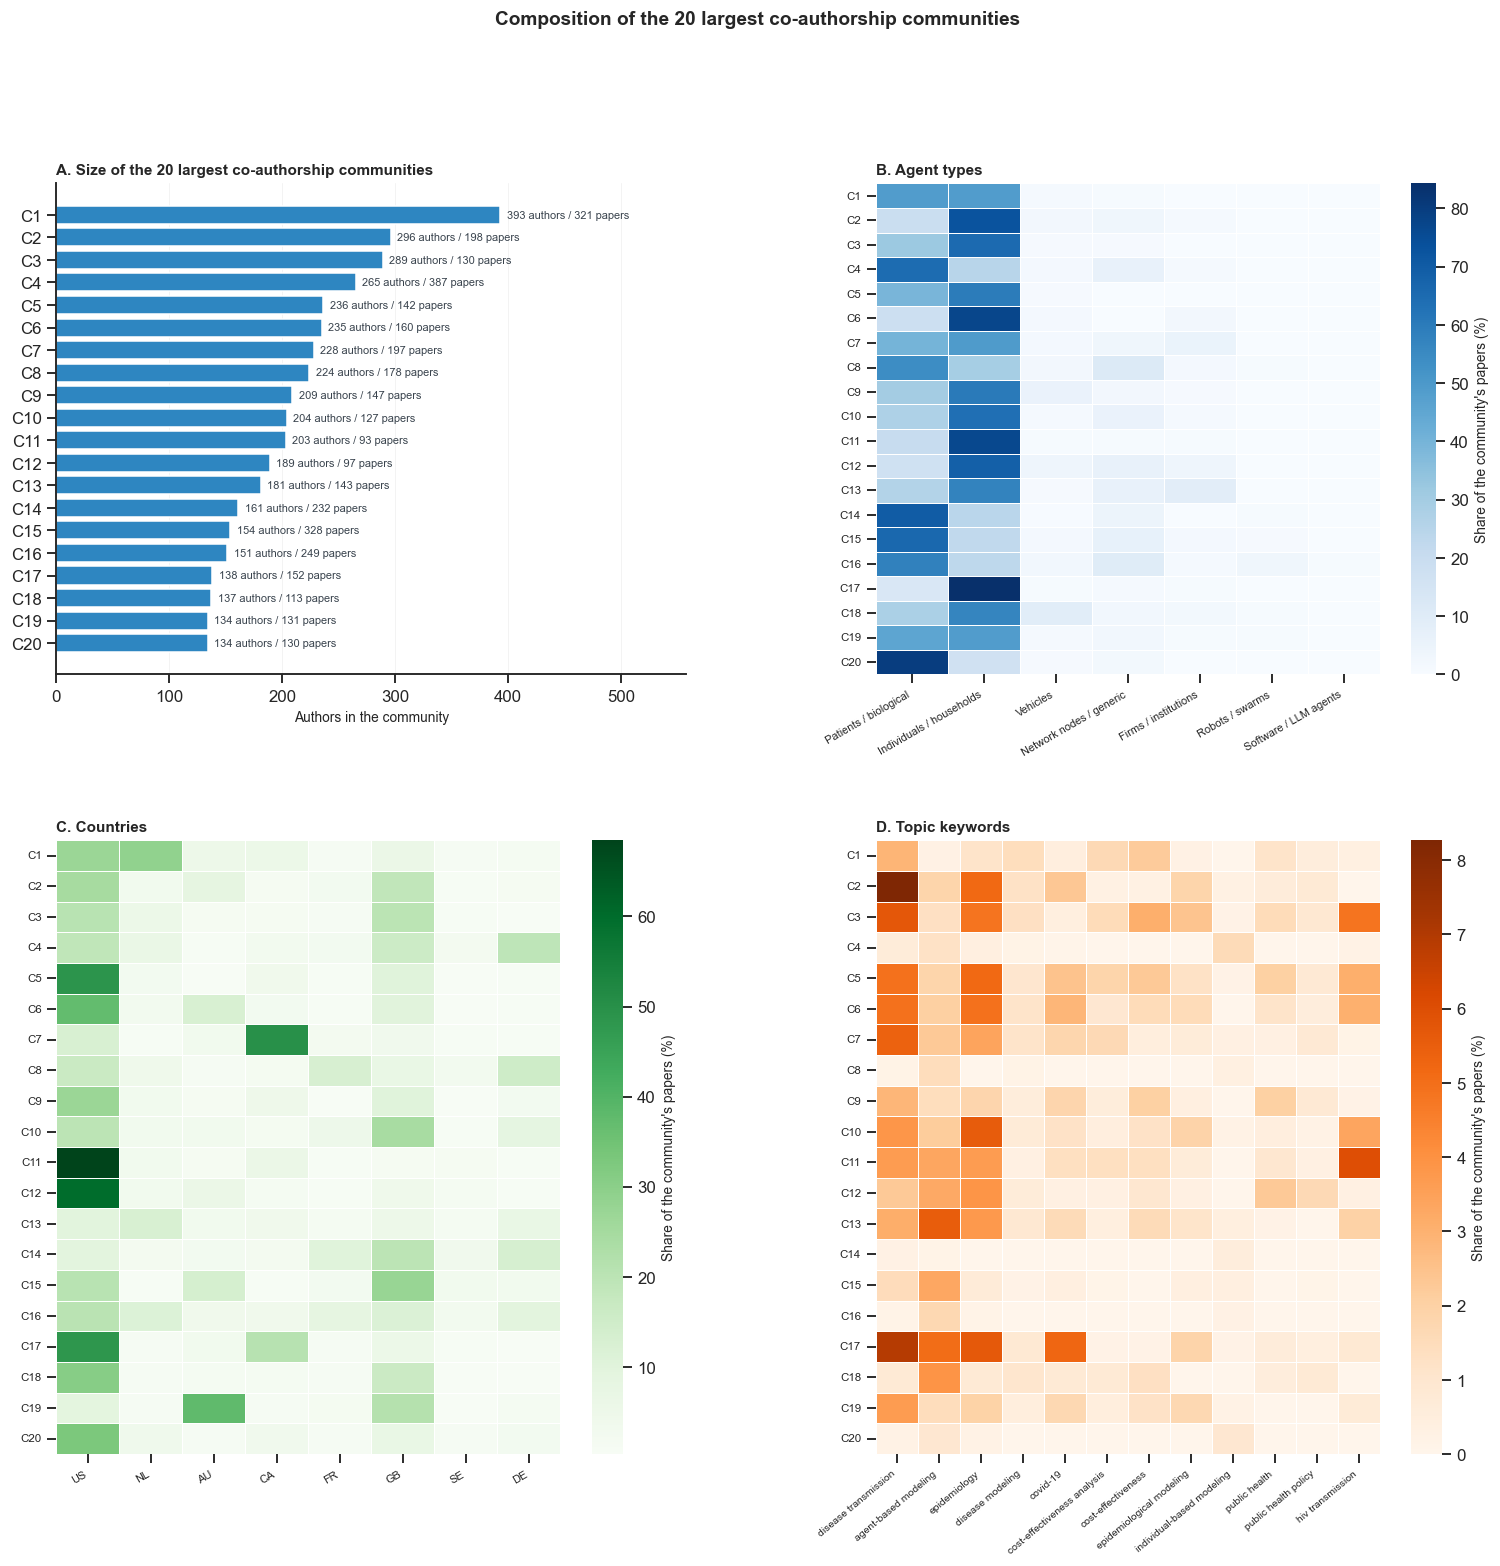

  [fig 10] 10_community_composition -> 10_community_composition_a, 10_community_composition_b, 10_community_composition_c, 10_community_composition_d  (figures_network/)


['10_community_composition_a',
 '10_community_composition_b',
 '10_community_composition_c',
 '10_community_composition_d']

In [20]:
# ================================================================ community composition (top 20)
# For each of the 20 largest Louvain communities: who is in it, and what its papers are about.
#
# Composition is measured at the PAPER level. A paper counts once for every community that one of its
# authors belongs to, so a paper bridging two communities contributes to both; the shares are
# within-community shares of that community's own paper pool, not a partition of the corpus.
# Centrality is the weighted degree inside Gp, the pruned detection graph - the same ranking the
# force layout uses - so "central" here means "central among the authors the detection actually saw".
import json as _json
from collections import Counter as _Counter, defaultdict as _defaultdict


def _to_list(v):
    if isinstance(v, list):
        return v
    if hasattr(v, "tolist"):
        return v.tolist()
    return []


_AGENT_RULES = [
    ("Individuals / households", [r"individual", r"household", r"citizen", r"resident", r"consumer",
                                  r"farmer", r"traveler", r"traveller", r"commuter", r"voter",
                                  r"pedestrian", r"human", r"people", r"person", r"population",
                                  r"worker"]),
    ("Patients / biological", [r"patient", r"cell", r"organism", r"bacteri", r"virus", r"biological",
                               r"molecul", r"gene", r"tumor", r"tumour", r"protein", r"neuron",
                               r"species", r"animal", r"insect"]),
    ("Vehicles", [r"vehicle", r"car", r"truck", r"bus", r"vessel", r"ship", r"aircraft", r"bike",
                  r"bicycle", r"uav", r"unmanned", r"drone", r"robotaxi"]),
    ("Robots / swarms", [r"robot", r"swarm", r"drone", r"uav"]),
    ("Software / LLM agents", [r"software", r"llm", r"language model", r"chatbot",
                               r"intelligent agent", r"virtual agent", r"gpt", r"ai agent"]),
    ("Firms / institutions", [r"firm", r"bank", r"compan", r"institution", r"government", r"regulator",
                              r"retailer", r"supplier", r"producer", r"organization", r"organisation",
                              r"hospital", r"school", r"investor", r"trader", r"policy maker"]),
    ("Network nodes / generic", [r"node", r"network", r"agent", r"entity", r"unit", r"autonomous",
                                 r"mobile agent", r"intelligent", r"unspecified"]),
]
_AGENT_RX = [(n, re.compile("|".join(p), re.I)) for n, p in _AGENT_RULES]


def _agent_tokens(raw):
    if not isinstance(raw, str) or not raw.strip():
        return []
    parts = [p.strip(" .;") for p in re.split(r"[,/;]| and ", raw.replace("not_applicable", ""))]
    out = []
    for p in parts:
        p = re.sub(r"\s+", " ", p).strip()
        if len(p) < 3:
            continue
        for name, rx in _AGENT_RX:
            if rx.search(p):
                out.append(name)
                break
    return out


# ---- author -> community, and paper -> communities
_comm = sorted(communities, key=len, reverse=True)
_comm_of = {a: i for i, mem in enumerate(_comm) for a in mem}

_paper_meta = {}
for _r in comm_meta.itertuples(index=False):
    _paper_meta[_r.doc_id] = {
        "countries": [str(c) for c in ((AUTHORS.get(_r.doc_id) or {}).get("c") or [])],
        "domain": str(_r.llama_primary_domain or "").strip(),
        "topics": [str(k).strip().lower() for k in _to_list(_r.llama_topic_keywords)
                   if str(k).strip()],
        "agents": _agent_tokens(_r.llama_agent_types),
        "year": int(_r.year_num),
        "n_authors": int(_r.n_authors or 0),
    }

_comm_papers = _defaultdict(set)
for _r in comm_meta.itertuples(index=False):
    for _nm in _to_list(_r.authors_ordered):
        _c = _comm_of.get(_nm)
        if _c is not None:
            _comm_papers[_c].add(_r.doc_id)

_wdeg = dict(Gp.degree(weight="weight"))
_deg = dict(Gp.degree())
# no eigenvector centrality here: it is undefined on a disconnected graph and pruning the
# giant component at degree >= 10 disconnects it. Weighted degree inside Gp is the ranking the
# layout uses, so that is what "central" means below.

TOP_N_COMM = 20
TOP_MEMBERS = 5
rows = []
for _ci in range(min(TOP_N_COMM, len(_comm))):
    _members = _comm[_ci]
    _papers = sorted(_comm_papers.get(_ci, ()))
    if not _papers:
        continue
    _top = sorted(_members, key=lambda a: -_wdeg.get(a, 0.0))[:TOP_MEMBERS]
    _ctry = _Counter()
    _topic = _Counter()
    _agent = _Counter()
    _dom = _Counter()
    for _d in _papers:
        _m = _paper_meta.get(_d)
        if not _m:
            continue
        _ctry.update(set(_m["countries"]))
        _topic.update(set(_m["topics"]))
        _agent.update(set(_m["agents"]))
        if _m["domain"]:
            _dom[_m["domain"]] += 1
    _yrs = [_paper_meta[_d]["year"] for _d in _papers if _d in _paper_meta]
    _na = [_paper_meta[_d]["n_authors"] for _d in _papers if _d in _paper_meta]
    rows.append({
        "community": _ci + 1,
        "members": len(_members),
        "papers": len(_papers),
        "top_members": "; ".join(
            f"{a} ({_wdeg.get(a, 0):.1f} wdeg / {_deg.get(a, 0)} deg)" for a in _top),
        "top_countries": "; ".join(f"{k} ({v})" for k, v in _ctry.most_common(3)),
        "top_topics": "; ".join(f"{k} ({v})" for k, v in _topic.most_common(3)),
        "top_agent_types": "; ".join(f"{k} ({v})" for k, v in _agent.most_common(3)),
        "top_domain": _dom.most_common(1)[0][0] if _dom else "",
        "median_year": int(np.median(_yrs)) if _yrs else 0,
        "mean_authors": round(float(np.mean(_na)), 2) if _na else 0.0,
        "_ctry": _ctry, "_topic": _topic, "_agent": _agent, "_members": _members,
    })

COMP = pd.DataFrame(rows)
print(f"communities reported: {len(COMP)} of {len(_comm):,} "
      f"(degree >= {DEG_PRUNE} subgraph, {Gp.number_of_nodes():,} authors)")
print(f"these 20 hold {int(COMP['members'].sum()):,} authors "
      f"({100 * COMP['members'].sum() / Gp.number_of_nodes():.1f} % of the pruned graph) and "
      f"{int(COMP['papers'].sum()):,} paper slots\n")

_pd_show = COMP.drop(columns=[c for c in COMP.columns if c.startswith("_")])
for _c in ("top_members", "top_countries", "top_topics", "top_agent_types", "top_domain"):
    _pd_show[_c] = _pd_show[_c].str.slice(0, 58)
display(_pd_show.style.hide(axis="index"))

COMP.drop(columns=[c for c in COMP.columns if c.startswith("_")]).to_csv(
    FIG_DIR / "community_composition_top20.csv", index=False, encoding="utf-8-sig")
print(f"saved -> {FIG_DIR / 'community_composition_top20.csv'}")

# ---------------------------------------------------------------- figure
_COUNTRIES = [c for c, _ in _Counter(
    k for r in rows for k in r["_ctry"]).most_common(8)]
_AGENTS = [a for a, _ in _Counter(k for r in rows for k in r["_agent"]).most_common(7)]
_TOPICS = [t for t, _ in _Counter(
    k for r in rows for k in r["_topic"]).most_common(12)]


def _share(idx, key, universe):
    vals = []
    for r in rows:
        tot = sum(r[key].values()) or 1
        vals.append([100 * r[key].get(u, 0) / tot for u in universe])
    return pd.DataFrame(vals, index=[f"C{r['community']}" for r in rows], columns=universe)


fig = plt.figure(figsize=(17.0, 15.0))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.25], hspace=0.30, wspace=0.30)

ax = fig.add_subplot(gs[0, 0])
_lab = [f"C{r['community']}" for r in rows]
ax.barh(_lab[::-1], [r["members"] for r in rows][::-1], color=C["abm"], edgecolor="white")
for i, r in enumerate(rows[::-1]):
    ax.text(r["members"] + max(x["members"] for x in rows) * 0.015, i,
            f"{r['members']:,} authors / {r['papers']:,} papers", va="center", fontsize=7.2,
            color="#3A444E")
ax.set_xlim(0, max(x["members"] for x in rows) * 1.42)
ax.set_xlabel("Authors in the community")
ax.set_title("A. Size of the 20 largest co-authorship communities", fontsize=10, fontweight="bold",
             loc="left")
ax.grid(axis="y", visible=False)

ax = fig.add_subplot(gs[0, 1])
_sh = _share(rows, "_agent", _AGENTS)
sns.heatmap(_sh, cmap="Blues", linewidths=0.6, linecolor="white", ax=ax,
            cbar_kws={"label": "Share of the community's papers (%)"})
ax.set_title("B. Agent types", fontsize=10, fontweight="bold", loc="left")
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7.2)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7.5)

ax = fig.add_subplot(gs[1, 0])
_sh = _share(rows, "_ctry", _COUNTRIES)
sns.heatmap(_sh, cmap="Greens", linewidths=0.6, linecolor="white", ax=ax,
            cbar_kws={"label": "Share of the community's papers (%)"})
ax.set_title("C. Countries", fontsize=10, fontweight="bold", loc="left")
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right", fontsize=7.2)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7.5)

ax = fig.add_subplot(gs[1, 1])
_sh = _share(rows, "_topic", _TOPICS)
sns.heatmap(_sh, cmap="Oranges", linewidths=0.6, linecolor="white", ax=ax,
            cbar_kws={"label": "Share of the community's papers (%)"})
ax.set_title("D. Topic keywords", fontsize=10, fontweight="bold", loc="left")
ax.set_xlabel("")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=6.8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7.5)

fig.suptitle("Composition of the 20 largest co-authorship communities",
             fontsize=12.5, fontweight="bold", y=0.985)
save(fig, "10_community_composition")


## 合作网络的时间维度（RQ1 补充）

见本节代码单元；实现位于 `tools/` 下对应脚本，命令行可直接复算。


In [ ]:
# ---- RQ1: team size / international share / period-sliced community structure ----
# 图15—17 只给汇总网络，看不出时间变化。这里补三件事：
#   1) 年度团队规模与国际合著比例（per-paper，不需要图）
#   2) 分时段独立做 Louvain：社区数、Q、跨社群边权占比、平均参与系数
#   3) 判别指标：关系存续率、相邻时段 ARI/NMI、跨时段同社群边权占比
# 实现放在 tools/rq1_temporal_network.py，命令行与笔记本共用一份代码。
import sys
if "tools" not in sys.path:
    sys.path.insert(0, "tools")
import rq1_temporal_network as rq1
rq1.main()
